# Minería de Datos – Premier League (2000–2025)



---
**Dataset:** English Premier League Match Data (2000/01 – 2024/25)  
**Registros:** 9,380 partidos | **Variables:** 22  
**Fuente:** Kaggle / datos estadísticos de la EPL

---

## Instalación e Importación de Librerías

In [1]:
# Instalación (solo si se ejecuta en Colab)
!pip install seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Estilo visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print(' Librerías cargadas correctamente')

 Librerías cargadas correctamente


---
## COMPRENSIÓN DE LOS DATOS

In [2]:

from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/Mineria_Datos/epl_final.csv'
df = pd.read_csv(ruta)

print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head(10)

Mounted at /content/drive
Dataset cargado: 9,380 filas × 22 columnas


,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0
5,2000/01,2000-08-19,Leicester,Aston Villa,0,0,D,0,0,D,...,4,3,5,4,12,12,2,3,0,0
6,2000/01,2000-08-19,Liverpool,Bradford,1,0,H,0,0,D,...,10,2,6,1,8,8,1,1,0,0
7,2000/01,2000-08-19,Sunderland,Arsenal,1,0,H,0,0,D,...,2,7,2,9,10,21,3,1,0,1
8,2000/01,2000-08-19,Tottenham,Ipswich,3,1,H,2,1,H,...,6,5,3,4,14,13,0,0,0,0
9,2000/01,2000-08-20,Man United,Newcastle,2,0,H,1,0,H,...,9,6,7,1,7,13,0,1,0,0


In [3]:
# ─── Descripción general ───
print('='*60)
print('TIPOS DE VARIABLES')
print('='*60)
print(df.dtypes)
print()
print('='*60)
print('ESTADÍSTICAS DESCRIPTIVAS')
print('='*60)
df.describe().round(2)

TIPOS DE VARIABLES
Season               object
MatchDate            object
HomeTeam             object
AwayTeam             object
FullTimeHomeGoals     int64
FullTimeAwayGoals     int64
FullTimeResult       object
HalfTimeHomeGoals     int64
HalfTimeAwayGoals     int64
HalfTimeResult       object
HomeShots             int64
AwayShots             int64
HomeShotsOnTarget     int64
AwayShotsOnTarget     int64
HomeCorners           int64
AwayCorners           int64
HomeFouls             int64
AwayFouls             int64
HomeYellowCards       int64
AwayYellowCards       int64
HomeRedCards          int64
AwayRedCards          int64
dtype: object

ESTADÍSTICAS DESCRIPTIVAS


,FullTimeHomeGoals,FullTimeAwayGoals,HalfTimeHomeGoals,HalfTimeAwayGoals,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
count,9380.00,9380.00,9380.00,9380.00,9380.00,9380.00,9380.00,9380.00,9380.00,9380.00,9380.00,9380.00,9380.00,9380.00,9380.00,9380.00
mean,1.54,1.18,0.69,0.52,13.62,10.81,5.97,4.69,6.04,4.77,11.28,11.77,1.47,1.79,0.06,0.09
std,1.31,1.16,0.84,0.74,5.36,4.70,3.27,2.75,3.11,2.75,3.75,3.92,1.22,1.29,0.25,0.29
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,1.00,0.00,0.00,0.00,10.00,7.00,4.00,3.00,4.00,3.00,9.00,9.00,1.00,1.00,0.00,0.00
50%,1.00,1.00,0.00,0.00,13.00,10.00,6.00,4.00,6.00,4.00,11.00,12.00,1.00,2.00,0.00,0.00
75%,2.00,2.00,1.00,1.00,17.00,14.00,8.00,6.00,8.00,6.00,14.00,14.00,2.00,3.00,0.00,0.00
max,9.00,9.00,5.00,5.00,43.00,37.00,24.00,20.00,20.00,19.00,33.00,29.00,7.00,9.00,3.00,2.00


In [4]:
# ─── Rango temporal ───
print(f'Temporadas cubiertas : {df["Season"].nunique()} ({df["Season"].min()} → {df["Season"].max()})')
print(f'Fechas               : {df["MatchDate"].min()} → {df["MatchDate"].max()}')
print(f'Equipos únicos       : {pd.concat([df["HomeTeam"], df["AwayTeam"]]).nunique()}')
print(f'Partidos totales     : {len(df):,}')

Temporadas cubiertas : 25 (2000/01 → 2024/25)
Fechas               : 2000-08-19 → 2025-05-05
Equipos únicos       : 46
Partidos totales     : 9,380


In [5]:
# ─── Valores nulos y duplicados ───
nulls = df.isnull().sum()
print('Valores nulos por columna:')
print(nulls[nulls > 0] if nulls.sum() > 0 else 'Ningún valor nulo encontrado')
print(f'\nFilas duplicadas: {df.duplicated().sum()}')

Valores nulos por columna:
Ningún valor nulo encontrado

Filas duplicadas: 0


In [6]:
# ─── Clasificación de variables ───
var_info = pd.DataFrame({
    'Variable': df.columns,
    'Tipo_Python': df.dtypes.values,
    'Tipo_Estadístico': [
        'Categórica Nominal', 'Categórica Ordinal', 'Categórica Nominal',
        'Categórica Nominal', 'Numérica Discreta', 'Numérica Discreta',
        'Categórica Nominal', 'Numérica Discreta', 'Numérica Discreta',
        'Categórica Nominal', 'Numérica Discreta', 'Numérica Discreta',
        'Numérica Discreta', 'Numérica Discreta', 'Numérica Discreta',
        'Numérica Discreta', 'Numérica Discreta', 'Numérica Discreta',
        'Numérica Discreta', 'Numérica Discreta', 'Numérica Discreta',
        'Numérica Discreta'
    ],
    'Relevancia': [
        'Alta', 'Media', 'Alta', 'Alta', 'Alta', 'Alta', 'Alta (target)',
        'Media', 'Media', 'Media', 'Alta', 'Alta', 'Alta', 'Alta',
        'Media', 'Media', 'Baja', 'Baja', 'Media', 'Media', 'Baja', 'Baja'
    ]
})
print(var_info.to_string(index=False))

         Variable Tipo_Python   Tipo_Estadístico    Relevancia
           Season      object Categórica Nominal          Alta
        MatchDate      object Categórica Ordinal         Media
         HomeTeam      object Categórica Nominal          Alta
         AwayTeam      object Categórica Nominal          Alta
FullTimeHomeGoals       int64  Numérica Discreta          Alta
FullTimeAwayGoals       int64  Numérica Discreta          Alta
   FullTimeResult      object Categórica Nominal Alta (target)
HalfTimeHomeGoals       int64  Numérica Discreta         Media
HalfTimeAwayGoals       int64  Numérica Discreta         Media
   HalfTimeResult      object Categórica Nominal         Media
        HomeShots       int64  Numérica Discreta          Alta
        AwayShots       int64  Numérica Discreta          Alta
HomeShotsOnTarget       int64  Numérica Discreta          Alta
AwayShotsOnTarget       int64  Numérica Discreta          Alta
      HomeCorners       int64  Numérica Discreta       

###
---
##  LIMPIEZA Y PREPARACIÓN DE DATOS

In [7]:

df_clean = df.copy()

# ─── 3.1  Conversión de fechas ───
# JUSTIFICACIÓN: MatchDate está como objeto string; convertir permite
# extraer mes/año para análisis temporales.
df_clean['MatchDate'] = pd.to_datetime(df_clean['MatchDate'])
df_clean['Year']  = df_clean['MatchDate'].dt.year
df_clean['Month'] = df_clean['MatchDate'].dt.month
print(' MatchDate convertida a datetime. Nuevas cols: Year, Month')

 MatchDate convertida a datetime. Nuevas cols: Year, Month


In [8]:
# ─── 3.2  Variables derivadas ───
# JUSTIFICACIÓN: Enriquecer el dataset con métricas calculables
# que resumen el desempeño ofensivo/defensivo de cada partido.

# Goles totales por partido
df_clean['TotalGoals'] = df_clean['FullTimeHomeGoals'] + df_clean['FullTimeAwayGoals']

# Diferencia de goles (perspectiva local)
df_clean['GoalDiff'] = df_clean['FullTimeHomeGoals'] - df_clean['FullTimeAwayGoals']

# Precisión de disparos (shots on target / total shots)
df_clean['HomeShotAccuracy'] = np.where(
    df_clean['HomeShots'] > 0,
    df_clean['HomeShotsOnTarget'] / df_clean['HomeShots'], 0
)
df_clean['AwayShotAccuracy'] = np.where(
    df_clean['AwayShots'] > 0,
    df_clean['AwayShotsOnTarget'] / df_clean['AwayShots'], 0
)

# Tarjetas totales por equipo
df_clean['HomeTotalCards'] = df_clean['HomeYellowCards'] + df_clean['HomeRedCards']
df_clean['AwayTotalCards'] = df_clean['AwayYellowCards'] + df_clean['AwayRedCards']

print('Variables derivadas creadas:', ['TotalGoals','GoalDiff',
      'HomeShotAccuracy','AwayShotAccuracy','HomeTotalCards','AwayTotalCards'])

Variables derivadas creadas: ['TotalGoals', 'GoalDiff', 'HomeShotAccuracy', 'AwayShotAccuracy', 'HomeTotalCards', 'AwayTotalCards']


In [9]:
# ─── 3.3  Verificación de nulos post-transformación ───
print('Nulos después de transformación:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print(f'Shape final: {df_clean.shape}')

Nulos después de transformación:
Series([], dtype: int64)
Shape final: (9380, 30)


In [10]:
# ─── 3.4  Codificación del resultado (para correlación) ───
# JUSTIFICACIÓN: FullTimeResult es categórica; la versión numérica
# permite incluirla en la matriz de correlación.
result_map = {'H': 1, 'D': 0, 'A': -1}
df_clean['ResultNumeric'] = df_clean['FullTimeResult'].map(result_map)

print('Distribución de resultados:')
print(df_clean['FullTimeResult'].value_counts())
print()
pct = df_clean['FullTimeResult'].value_counts(normalize=True)*100
print('Porcentajes:')
print(pct.round(1))

Distribución de resultados:
FullTimeResult
H    4299
A    2768
D    2313
Name: count, dtype: int64

Porcentajes:
FullTimeResult
H    45.8
A    29.5
D    24.7
Name: proportion, dtype: float64


In [11]:
# ─── 3.5  Resumen de decisiones de limpieza ───
print("""
┌──────────────────────────────────────────────────────────┐
│           RESUMEN DE DECISIONES DE LIMPIEZA              │
├──────────────────────────────────────────────────────────┤
│ 1. Sin valores nulos → No se eliminó ninguna fila        │
│ 2. Sin duplicados   → No se eliminó ninguna fila         │
│ 3. MatchDate        → Convertida a datetime              │
│ 4. Variables nuevas → 6 columnas derivadas               │
│ 5. ResultNumeric    → Codificación H=1, D=0, A=-1        │
└──────────────────────────────────────────────────────────┘
""")


┌──────────────────────────────────────────────────────────┐
│           RESUMEN DE DECISIONES DE LIMPIEZA              │
├──────────────────────────────────────────────────────────┤
│ 1. Sin valores nulos → No se eliminó ninguna fila        │
│ 2. Sin duplicados   → No se eliminó ninguna fila         │
│ 3. MatchDate        → Convertida a datetime              │
│ 4. Variables nuevas → 6 columnas derivadas               │
│ 5. ResultNumeric    → Codificación H=1, D=0, A=-1        │
└──────────────────────────────────────────────────────────┘



---
## EDA – ANÁLISIS EXPLORATORIO DE DATOS

###  Distribución de la Variable Objetivo: Resultado del Partido

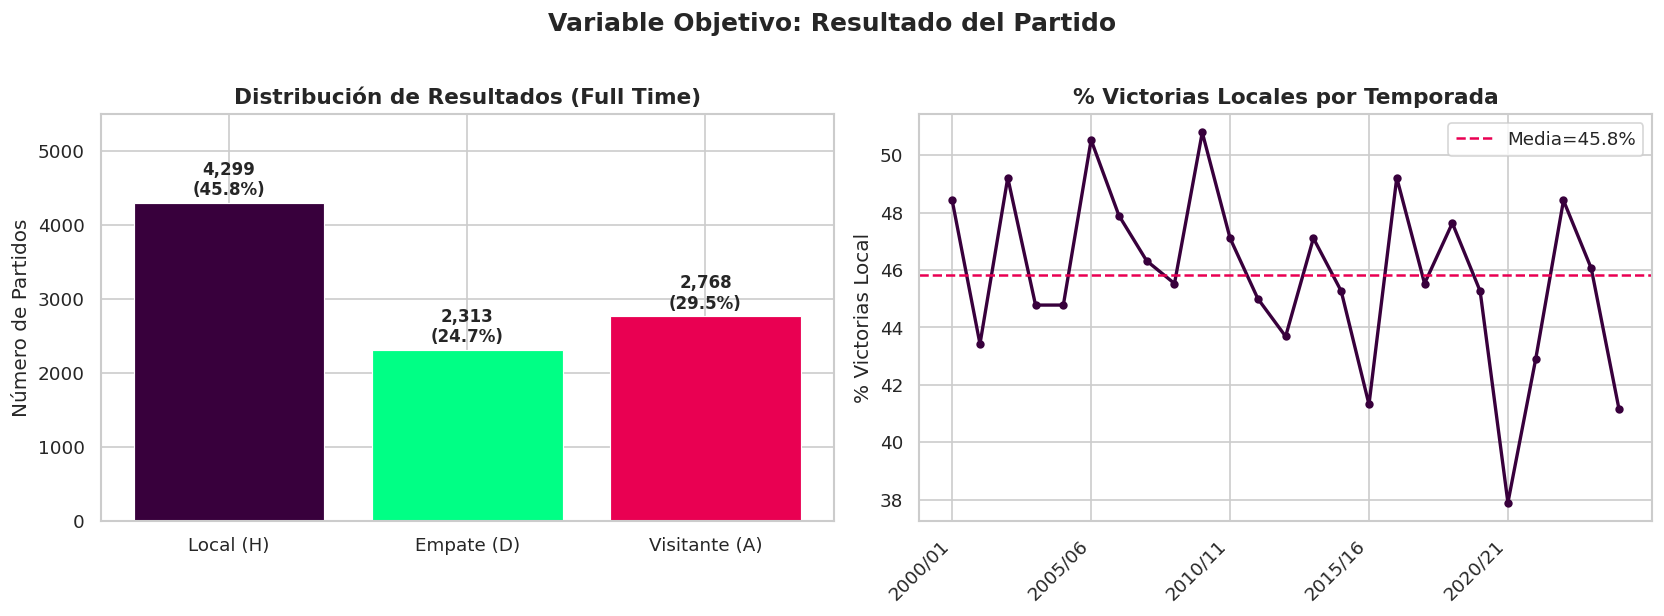


 INTERPRETACIÓN: La victoria local domina (~46%), seguida del visitante (~29%) y empate (~25%).
   La ventaja de localía ha DISMINUIDO tras la pandemia (2020/21), posiblemente sin público.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo de resultados
colors = ['#38003c', '#00ff85', '#e90052']
labels = ['Local (H)', 'Empate (D)', 'Visitante (A)']
counts = [df_clean['FullTimeResult'].value_counts()['H'],
          df_clean['FullTimeResult'].value_counts()['D'],
          df_clean['FullTimeResult'].value_counts()['A']]

bars = axes[0].bar(labels, counts, color=colors, edgecolor='white', linewidth=0.7)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}\n({count/len(df_clean)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Distribución de Resultados (Full Time)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de Partidos')
axes[0].set_ylim(0, 5500)

# Evolución temporal de victorias locales por temporada
home_wins_pct = df_clean.groupby('Season').apply(
    lambda x: (x['FullTimeResult']=='H').mean()*100
).reset_index()
home_wins_pct.columns = ['Season','HomePct']
axes[1].plot(range(len(home_wins_pct)), home_wins_pct['HomePct'],
             color='#38003c', marker='o', markersize=4, linewidth=2)
axes[1].axhline(home_wins_pct['HomePct'].mean(), color='#e90052',
                linestyle='--', linewidth=1.5, label=f'Media={home_wins_pct["HomePct"].mean():.1f}%')
axes[1].set_title('% Victorias Locales por Temporada', fontsize=13, fontweight='bold')
axes[1].set_ylabel('% Victorias Local')
axes[1].set_xticks(range(0, len(home_wins_pct), 5))
axes[1].set_xticklabels(home_wins_pct['Season'].iloc[::5], rotation=45, ha='right')
axes[1].legend()

plt.suptitle('Variable Objetivo: Resultado del Partido', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_resultado.png', bbox_inches='tight', dpi=150)
plt.show()
print('\n INTERPRETACIÓN: La victoria local domina (~46%), seguida del visitante (~29%) y empate (~25%).')
print('   La ventaja de localía ha DISMINUIDO tras la pandemia (2020/21), posiblemente sin público.')



### Histogramas – Distribución de Variables Numéricas Clave

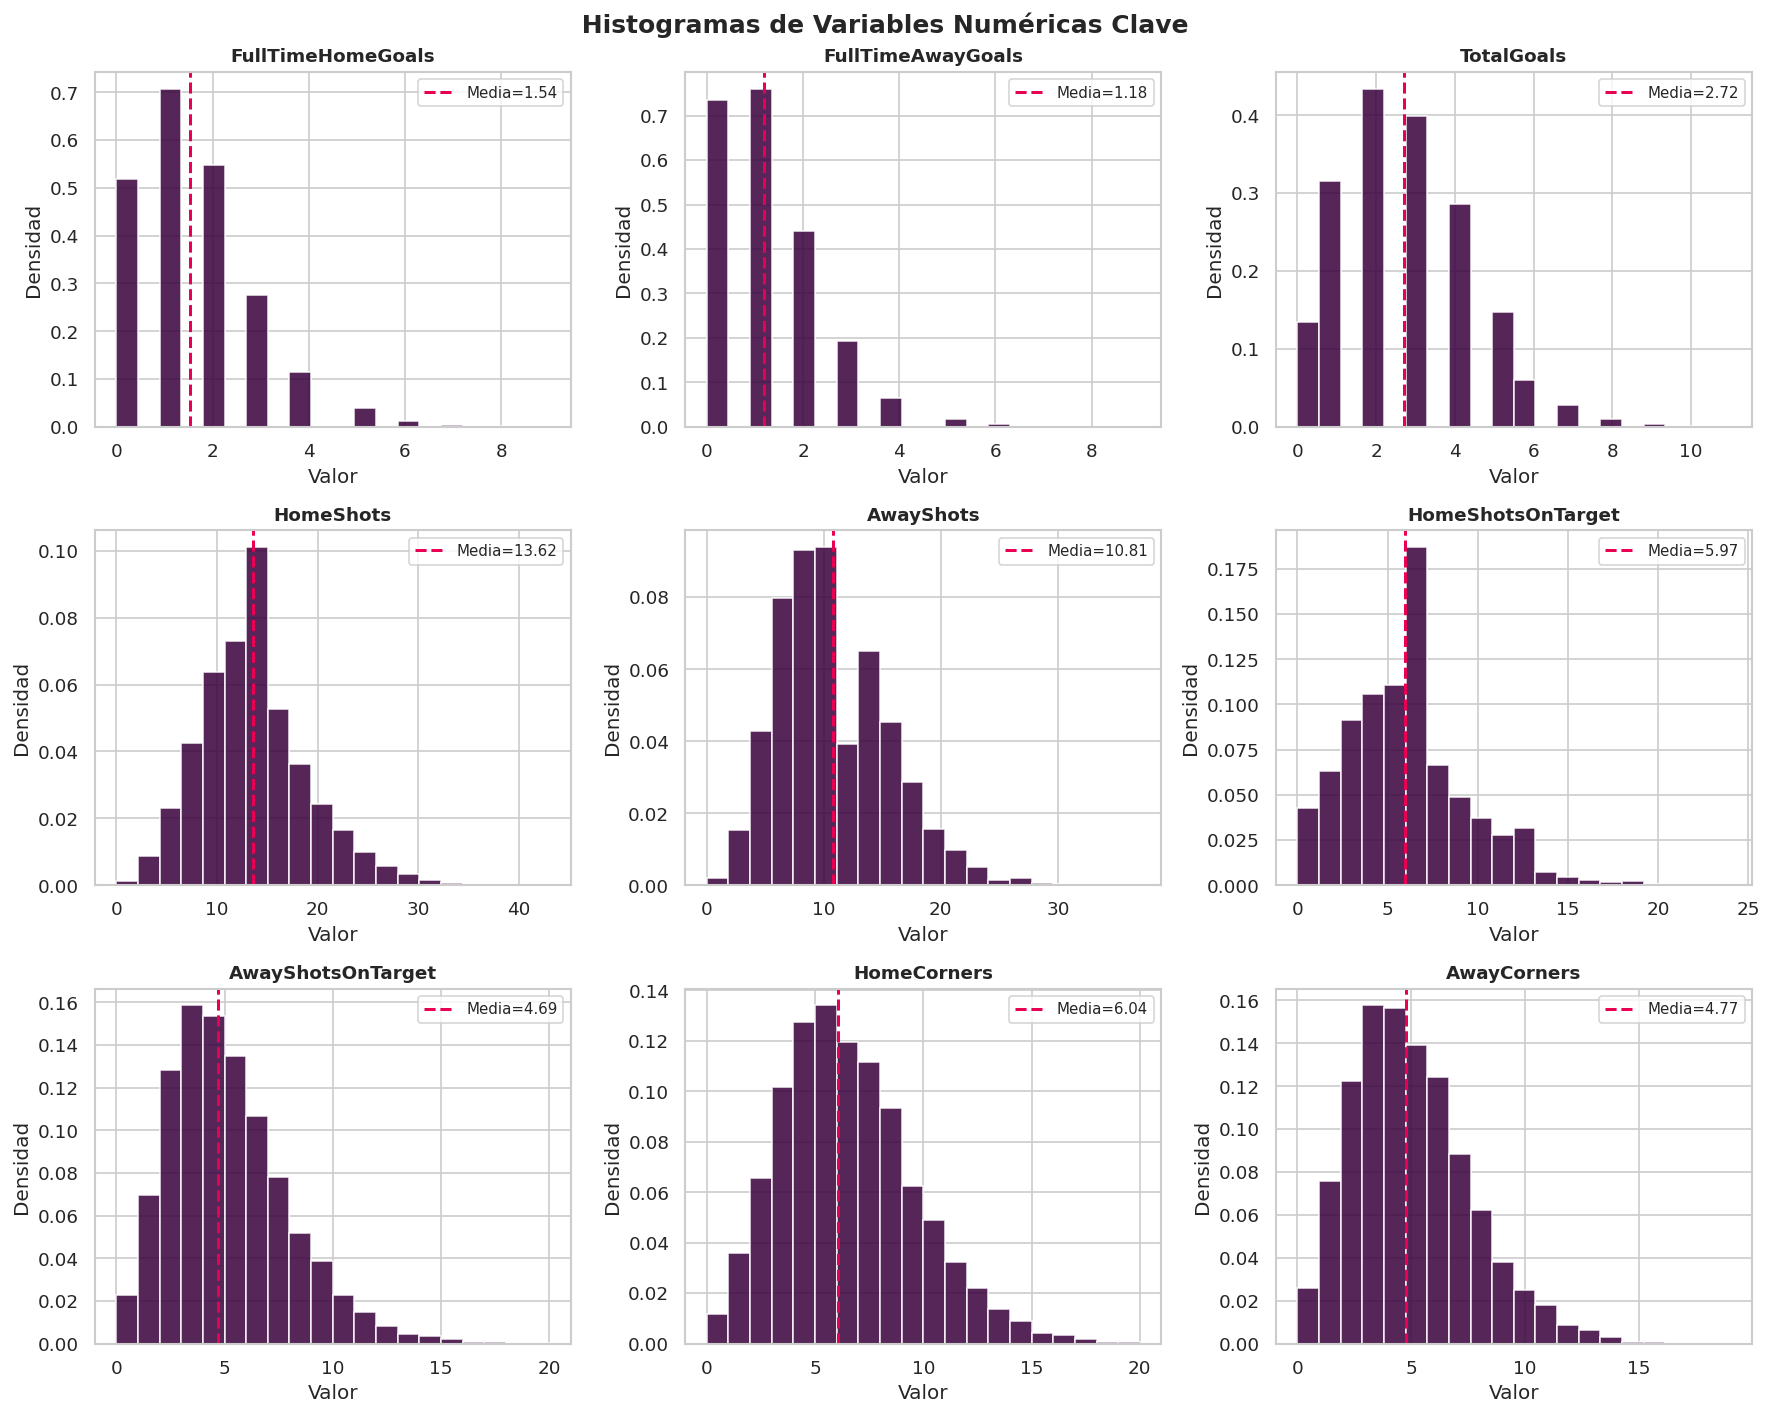


 INTERPRETACIÓN:
  - Goles (FT Home/Away): distribución sesgada a la derecha (Poisson-like).
  - Los partidos de 1-2 goles por equipo son los más comunes.
  - TotalGoals: mayoría de partidos entre 1 y 4 goles totales.
  - Disparos: distribución aproximadamente normal, media ~13 (local) y ~11 (visitante).


In [13]:
num_vars = ['FullTimeHomeGoals', 'FullTimeAwayGoals', 'TotalGoals',
            'HomeShots', 'AwayShots', 'HomeShotsOnTarget',
            'AwayShotsOnTarget', 'HomeCorners', 'AwayCorners']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, var in enumerate(num_vars):
    axes[i].hist(df_clean[var], bins=20, color='#38003c', edgecolor='white',
                 alpha=0.85, density=True)
    axes[i].set_title(var, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Densidad')
    # Línea de media
    axes[i].axvline(df_clean[var].mean(), color='#e90052',
                    linestyle='--', linewidth=1.8,
                    label=f'Media={df_clean[var].mean():.2f}')
    axes[i].legend(fontsize=9)

plt.suptitle(' Histogramas de Variables Numéricas Clave', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_histogramas.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n INTERPRETACIÓN:')
print('  - Goles (FT Home/Away): distribución sesgada a la derecha (Poisson-like).')
print('  - Los partidos de 1-2 goles por equipo son los más comunes.')
print('  - TotalGoals: mayoría de partidos entre 1 y 4 goles totales.')
print('  - Disparos: distribución aproximadamente normal, media ~13 (local) y ~11 (visitante).')

### Boxplots – Detección de Outliers por Resultado

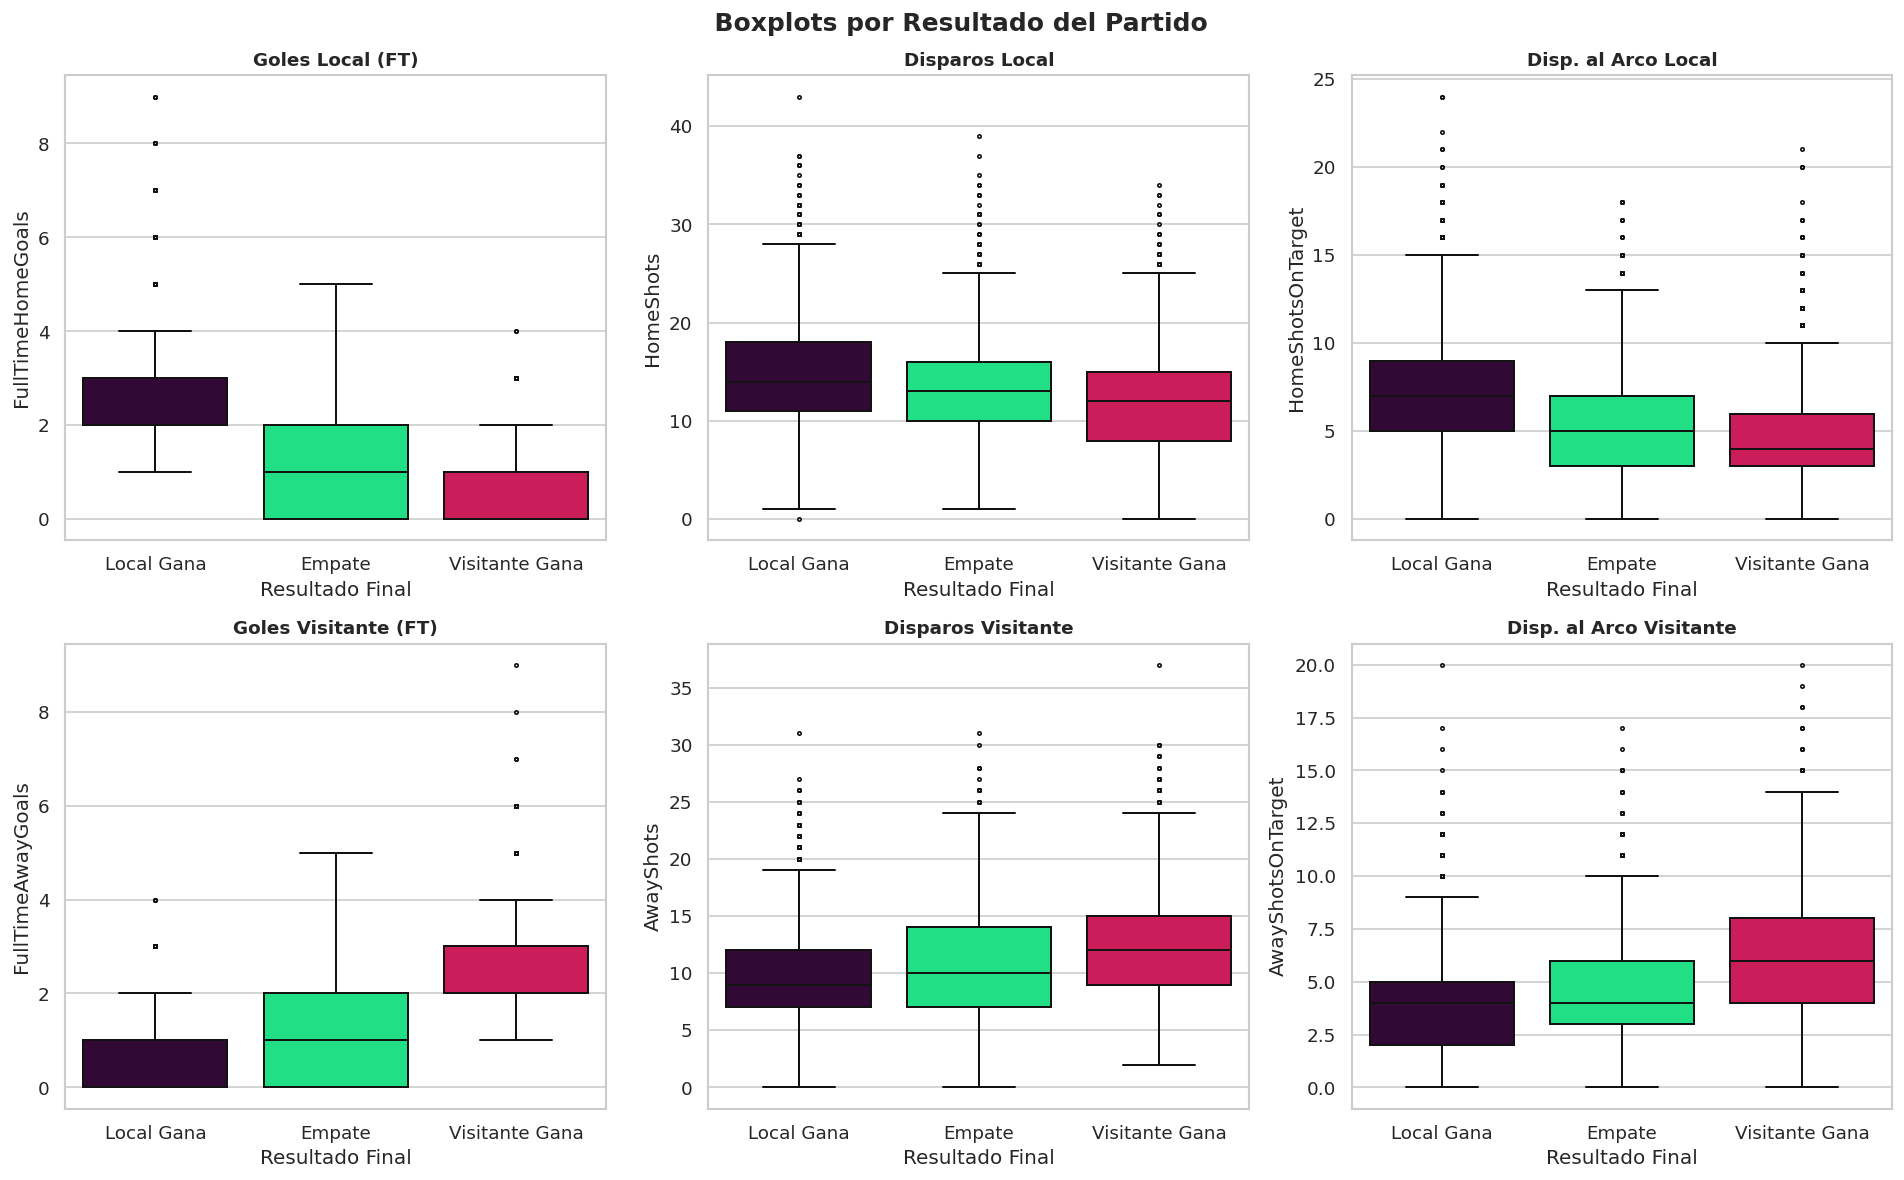


 INTERPRETACIÓN:
  - Cuando el local gana, el promedio de goles locales es ~2.5 vs ~0.4 del visitante.
  - Los disparos al arco muestran diferencia estadísticamente clara entre ganadores y perdedores.
  - Outliers: partidos con 8-9 goles (raros pero reales, no son errores).


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

box_vars = [
    ('FullTimeHomeGoals', 'Goles Local (FT)'),
    ('HomeShots',         'Disparos Local'),
    ('HomeShotsOnTarget', 'Disp. al Arco Local'),
    ('FullTimeAwayGoals', 'Goles Visitante (FT)'),
    ('AwayShots',         'Disparos Visitante'),
    ('AwayShotsOnTarget', 'Disp. al Arco Visitante'),
]

palette = {'H': '#38003c', 'D': '#00ff85', 'A': '#e90052'}
order   = ['H', 'D', 'A']

for i, (var, title) in enumerate(box_vars):
    sns.boxplot(data=df_clean, x='FullTimeResult', y=var,
                order=order, palette=palette, ax=axes[i],
                linewidth=1.2, fliersize=2)
    axes[i].set_title(title, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Resultado Final')
    axes[i].set_xticklabels(['Local Gana', 'Empate', 'Visitante Gana'])

plt.suptitle('  Boxplots por Resultado del Partido', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n INTERPRETACIÓN:')
print('  - Cuando el local gana, el promedio de goles locales es ~2.5 vs ~0.4 del visitante.')
print('  - Los disparos al arco muestran diferencia estadísticamente clara entre ganadores y perdedores.')
print('  - Outliers: partidos con 8-9 goles (raros pero reales, no son errores).')

### Scatterplots – Relaciones entre Variables

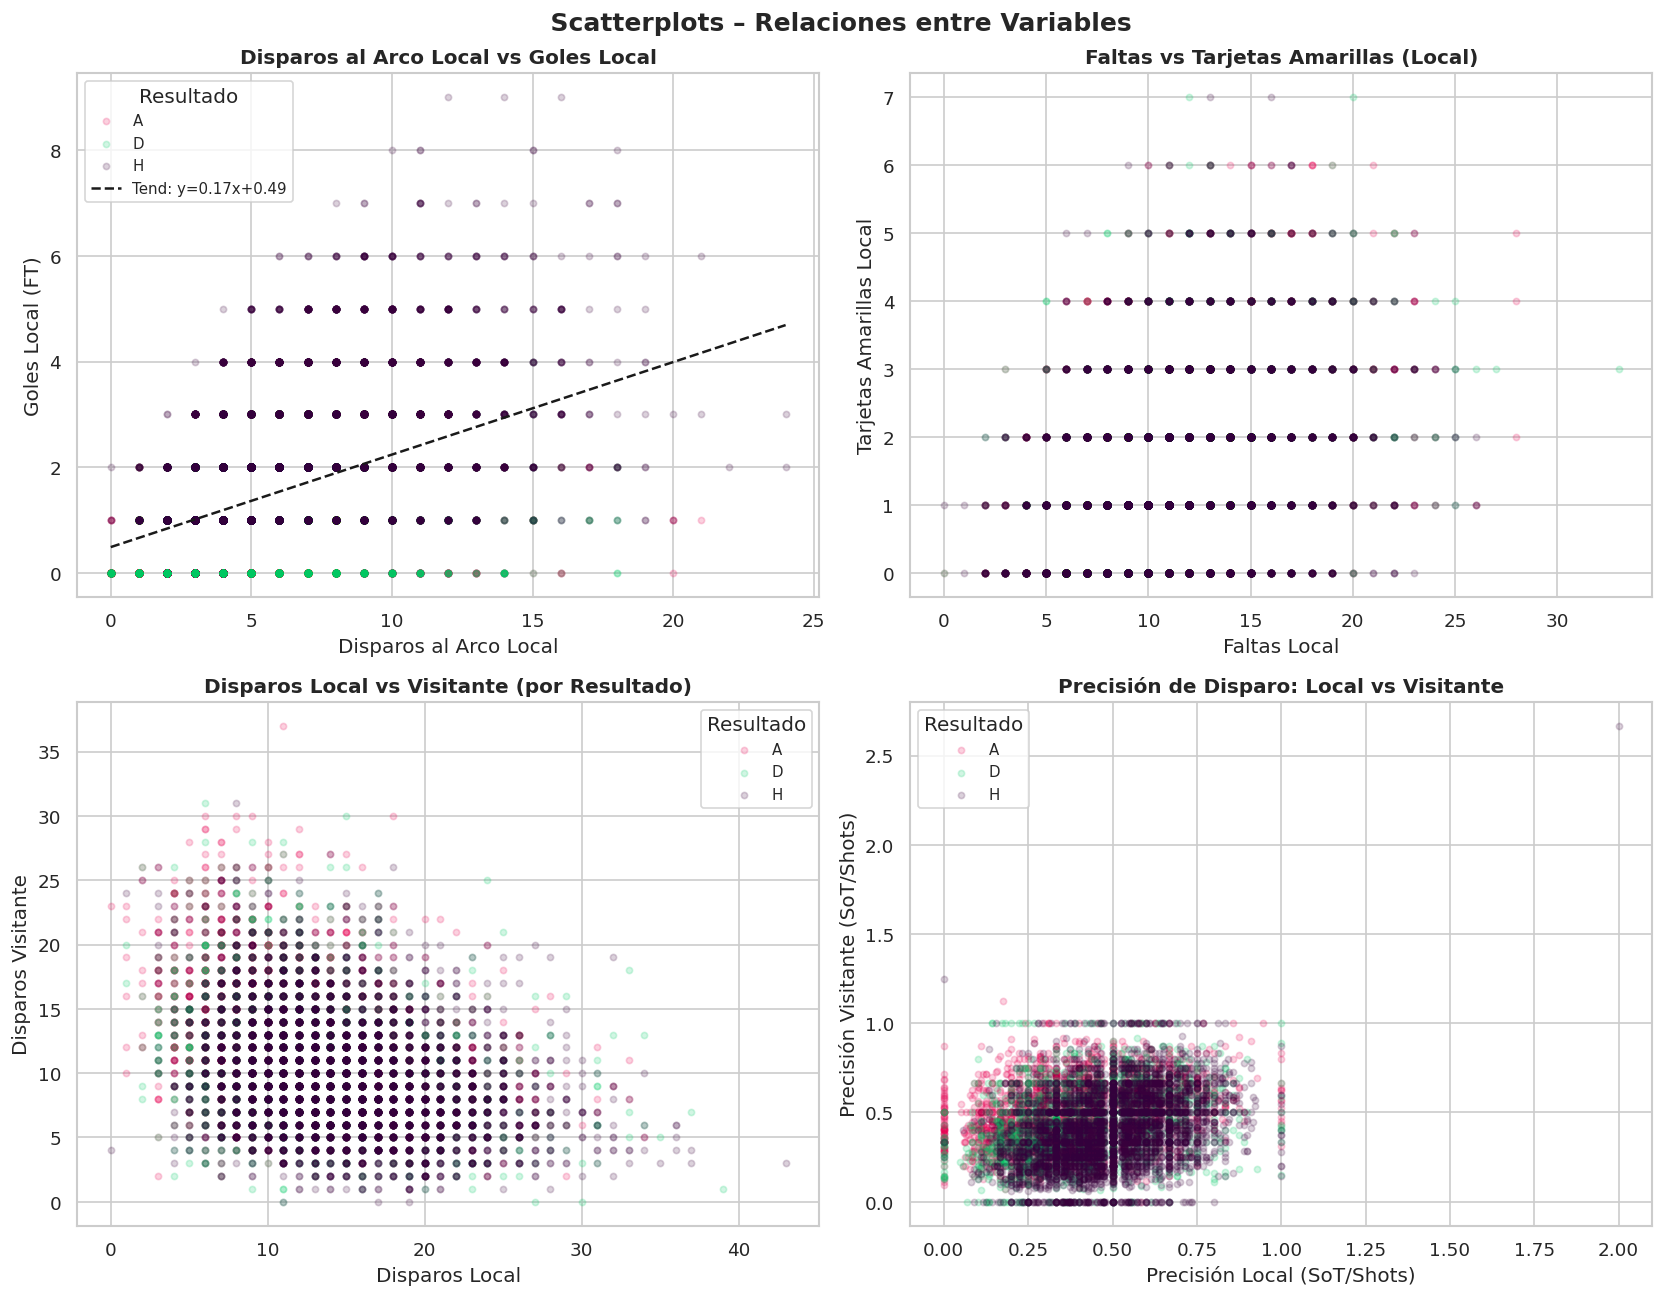


 INTERPRETACIÓN:
  - Fuerte relación lineal entre disparos al arco y goles (r ≈ 0.65).
  - Las faltas tienen correlación moderada con tarjetas amarillas.
  - Cuando el local gana, sus disparos superan claramente a los del visitante.
  - La precisión de tiro es similar entre equipos; la cantidad importa más.


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

palette_scatter = {'H': '#38003c', 'D': '#00cc66', 'A': '#e90052'}

# 1. Disparos al arco local vs Goles local
for result, grp in df_clean.groupby('FullTimeResult'):
    axes[0,0].scatter(grp['HomeShotsOnTarget'], grp['FullTimeHomeGoals'],
                      alpha=0.18, s=14, color=palette_scatter[result], label=result)
axes[0,0].set_xlabel('Disparos al Arco Local')
axes[0,0].set_ylabel('Goles Local (FT)')
axes[0,0].set_title('Disparos al Arco Local vs Goles Local', fontweight='bold')
axes[0,0].legend(title='Resultado')

# Línea de tendencia
m, b = np.polyfit(df_clean['HomeShotsOnTarget'], df_clean['FullTimeHomeGoals'], 1)
x_line = np.linspace(0, df_clean['HomeShotsOnTarget'].max(), 100)
axes[0,0].plot(x_line, m*x_line + b, 'k--', linewidth=1.5, label=f'Tend: y={m:.2f}x+{b:.2f}')
axes[0,0].legend(title='Resultado', fontsize=9)

# 2. Fouls vs Tarjetas amarillas (local)
for result, grp in df_clean.groupby('FullTimeResult'):
    axes[0,1].scatter(grp['HomeFouls'], grp['HomeYellowCards'],
                      alpha=0.18, s=14, color=palette_scatter[result], label=result)
axes[0,1].set_xlabel('Faltas Local')
axes[0,1].set_ylabel('Tarjetas Amarillas Local')
axes[0,1].set_title('Faltas vs Tarjetas Amarillas (Local)', fontweight='bold')

# 3. Disparos totales local vs visitante
for result, grp in df_clean.groupby('FullTimeResult'):
    axes[1,0].scatter(grp['HomeShots'], grp['AwayShots'],
                      alpha=0.18, s=14, color=palette_scatter[result], label=result)
axes[1,0].set_xlabel('Disparos Local')
axes[1,0].set_ylabel('Disparos Visitante')
axes[1,0].set_title('Disparos Local vs Visitante (por Resultado)', fontweight='bold')
axes[1,0].legend(title='Resultado', fontsize=9)

# 4. Precisión de tiro: local vs visitante
for result, grp in df_clean.groupby('FullTimeResult'):
    axes[1,1].scatter(grp['HomeShotAccuracy'], grp['AwayShotAccuracy'],
                      alpha=0.18, s=14, color=palette_scatter[result], label=result)
axes[1,1].set_xlabel('Precisión Local (SoT/Shots)')
axes[1,1].set_ylabel('Precisión Visitante (SoT/Shots)')
axes[1,1].set_title('Precisión de Disparo: Local vs Visitante', fontweight='bold')
axes[1,1].legend(title='Resultado', fontsize=9)

plt.suptitle('  Scatterplots – Relaciones entre Variables', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n INTERPRETACIÓN:')
print('  - Fuerte relación lineal entre disparos al arco y goles (r ≈ 0.65).')
print('  - Las faltas tienen correlación moderada con tarjetas amarillas.')
print('  - Cuando el local gana, sus disparos superan claramente a los del visitante.')
print('  - La precisión de tiro es similar entre equipos; la cantidad importa más.')

### Matriz de Correlación




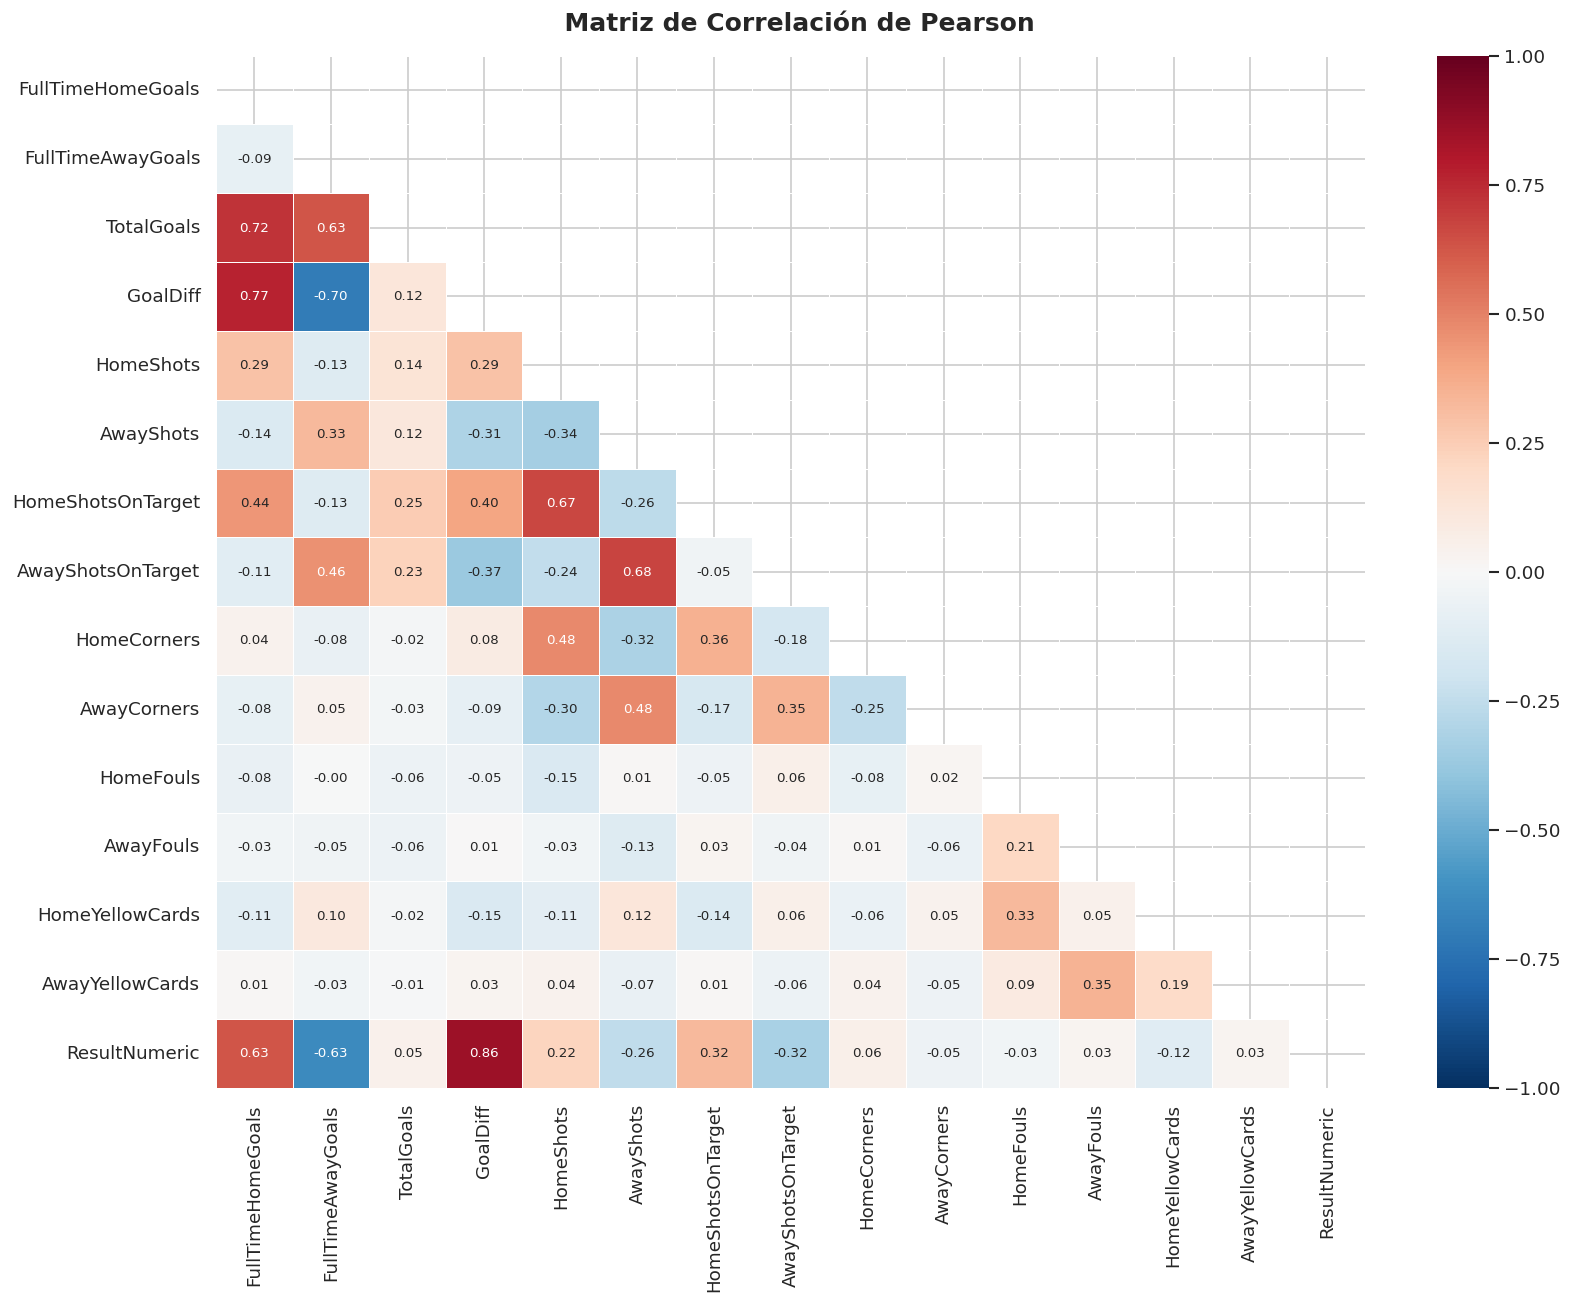


 CORRELACIONES CON ResultNumeric (ordenadas):
GoalDiff             0.857
FullTimeHomeGoals    0.630
HomeShotsOnTarget    0.324
HomeShots            0.225
HomeCorners          0.058
TotalGoals           0.053
AwayFouls            0.031
AwayYellowCards      0.029
HomeFouls           -0.035
AwayCorners         -0.049
HomeYellowCards     -0.118
AwayShots           -0.258
AwayShotsOnTarget   -0.321
FullTimeAwayGoals   -0.635


In [16]:
corr_cols = [
    'FullTimeHomeGoals', 'FullTimeAwayGoals', 'TotalGoals', 'GoalDiff',
    'HomeShots', 'AwayShots', 'HomeShotsOnTarget', 'AwayShotsOnTarget',
    'HomeCorners', 'AwayCorners', 'HomeFouls', 'AwayFouls',
    'HomeYellowCards', 'AwayYellowCards', 'ResultNumeric'
]

corr_matrix = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # solo triángulo inferior
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor='white',
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('  Matriz de Correlación de Pearson', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig5_correlacion.png', bbox_inches='tight', dpi=150)
plt.show()

# Top correlaciones con el resultado
print('\n CORRELACIONES CON ResultNumeric (ordenadas):')
corr_result = corr_matrix['ResultNumeric'].drop('ResultNumeric').sort_values(ascending=False)
print(corr_result.round(3).to_string())

### Análisis Adicional – Goles por Temporada y Tendencia

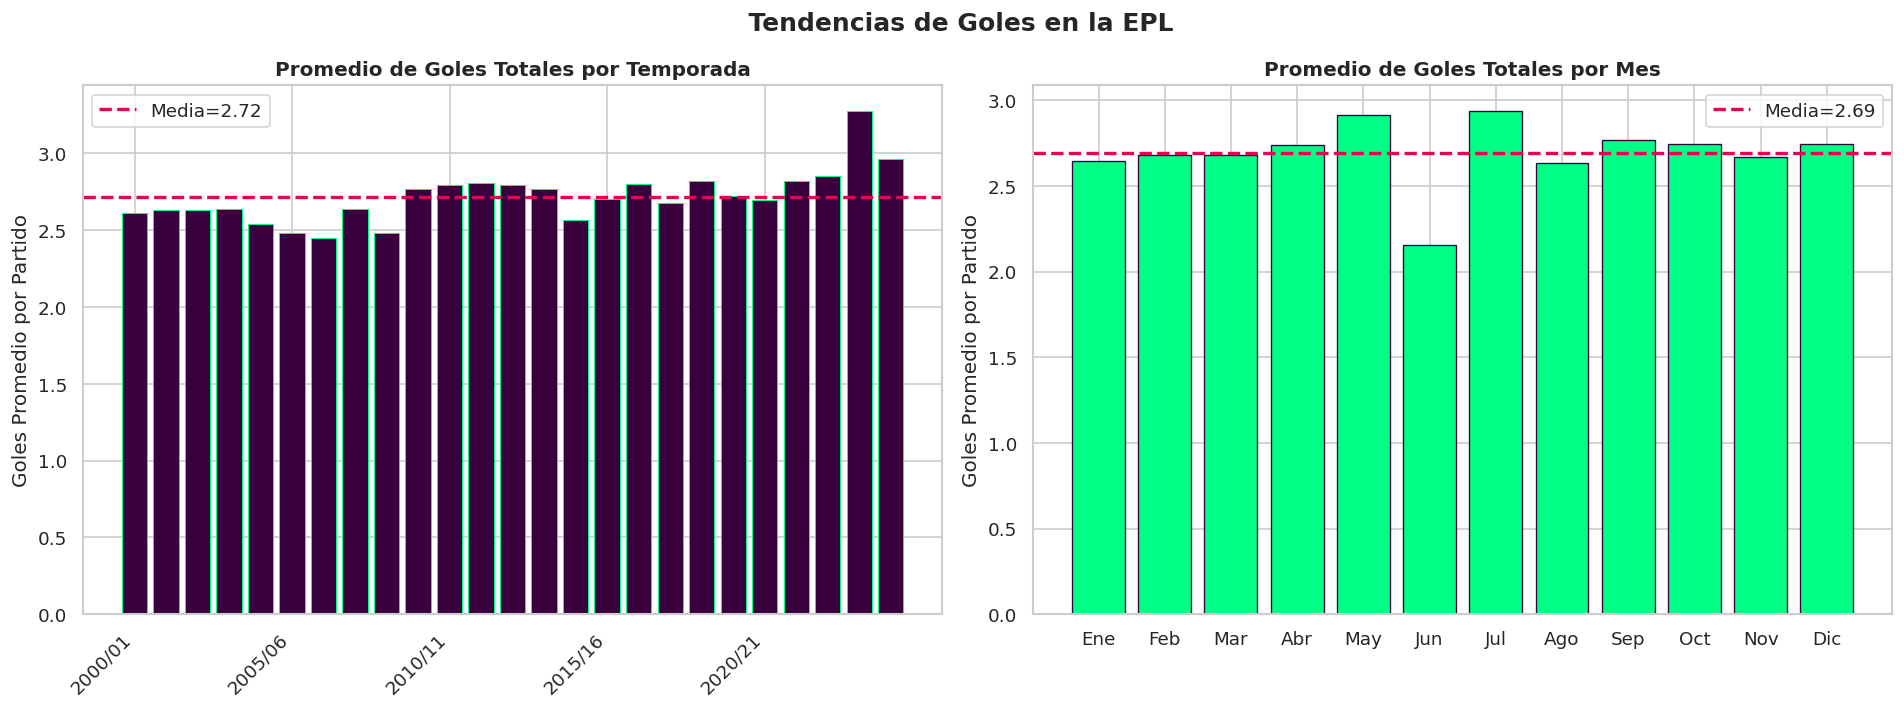


 INTERPRETACIÓN:
  - El promedio de goles se ha mantenido estable (~2.7/partido) durante 25 años.
  - Diciembre y enero (festivos) muestran ligera caída, posiblemente por cansancio físico.
  - La temporada 2020/21 (sin público) registró un leve descenso en goles locales.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Promedio de goles totales por temporada
goals_season = df_clean.groupby('Season')['TotalGoals'].mean().reset_index()
axes[0].bar(range(len(goals_season)), goals_season['TotalGoals'],
            color='#38003c', edgecolor='#00ff85', linewidth=0.6)
axes[0].axhline(goals_season['TotalGoals'].mean(), color='#e90052',
                linestyle='--', linewidth=2,
                label=f'Media={goals_season["TotalGoals"].mean():.2f}')
axes[0].set_title('Promedio de Goles Totales por Temporada', fontweight='bold')
axes[0].set_ylabel('Goles Promedio por Partido')
axes[0].set_xticks(range(0, len(goals_season), 5))
axes[0].set_xticklabels(goals_season['Season'].iloc[::5], rotation=45, ha='right')
axes[0].legend()

# Distribución de goles por mes
monthly = df_clean.groupby('Month')['TotalGoals'].mean()
month_names = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
axes[1].bar(monthly.index, monthly.values, color='#00ff85',
            edgecolor='#38003c', linewidth=0.8)
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(month_names)
axes[1].set_title('Promedio de Goles Totales por Mes', fontweight='bold')
axes[1].set_ylabel('Goles Promedio por Partido')
axes[1].axhline(monthly.mean(), color='#e90052', linestyle='--',
                linewidth=2, label=f'Media={monthly.mean():.2f}')
axes[1].legend()

plt.suptitle('  Tendencias de Goles en la EPL', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_tendencias.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n INTERPRETACIÓN:')
print('  - El promedio de goles se ha mantenido estable (~2.7/partido) durante 25 años.')
print('  - Diciembre y enero (festivos) muestran ligera caída, posiblemente por cansancio físico.')
print('  - La temporada 2020/21 (sin público) registró un leve descenso en goles locales.')

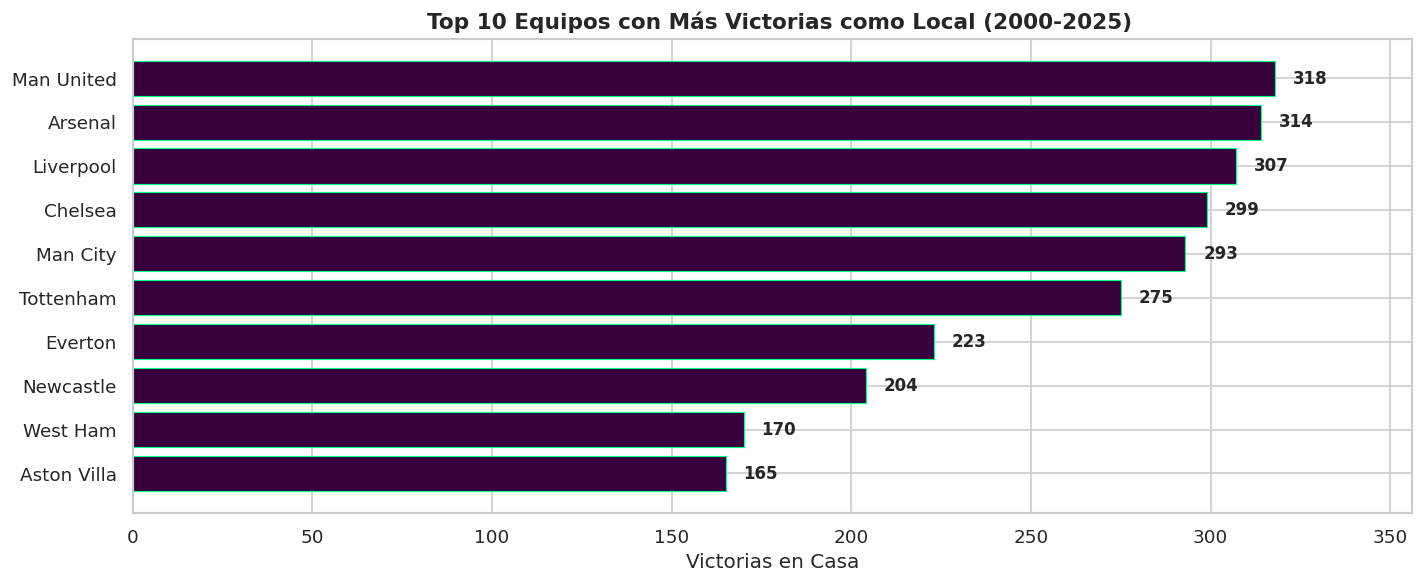


 Manchester United, Arsenal, Chelsea y Liverpool dominan la ventaja de localía.


In [18]:
# Top 10 equipos con más victorias de local
top_home = (
    df_clean[df_clean['FullTimeResult']=='H']
    .groupby('HomeTeam').size()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_home.index[::-1], top_home.values[::-1],
               color='#38003c', edgecolor='#00ff85', linewidth=0.7)
for bar, val in zip(bars, top_home.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10, fontweight='bold')
ax.set_title('  Top 10 Equipos con Más Victorias como Local (2000-2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Victorias en Casa')
ax.set_xlim(0, top_home.max()*1.12)
plt.tight_layout()
plt.savefig('fig7_top_equipos.png', bbox_inches='tight', dpi=150)
plt.show()
print('\n Manchester United, Arsenal, Chelsea y Liverpool dominan la ventaja de localía.')

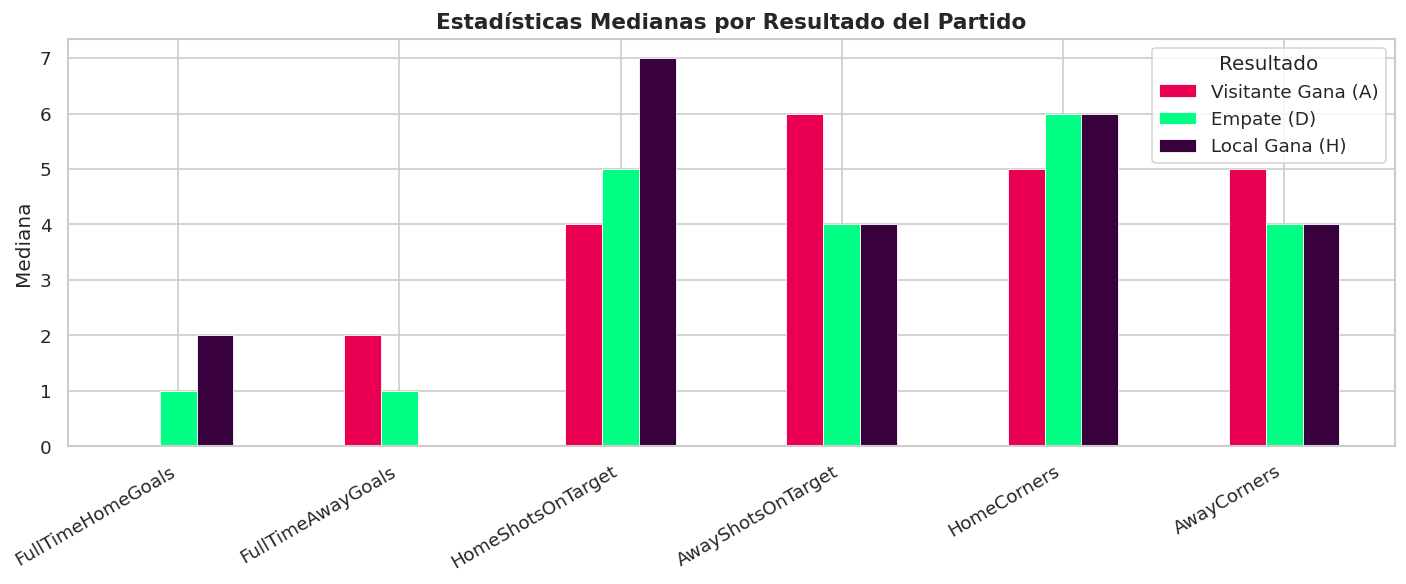

In [19]:
# Comparación de estadísticas medianas por resultado
stats_by_result = df_clean.groupby('FullTimeResult')[[
    'FullTimeHomeGoals','FullTimeAwayGoals',
    'HomeShotsOnTarget','AwayShotsOnTarget',
    'HomeCorners','AwayCorners'
]].median().round(2)
stats_by_result.index = ['Visitante Gana (A)', 'Empate (D)', 'Local Gana (H)']

fig, ax = plt.subplots(figsize=(12, 5))
stats_by_result.T.plot(kind='bar', ax=ax,
                       color=['#e90052','#00ff85','#38003c'],
                       edgecolor='white', linewidth=0.5)
ax.set_title('Estadísticas Medianas por Resultado del Partido',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Mediana')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Resultado')
plt.tight_layout()
plt.savefig('fig8_medians.png', bbox_inches='tight', dpi=150)
plt.show()

### Interpretación – Estadísticas Medianas por Resultado

Este gráfico muestra cómo las estadísticas clave de un partido cambian en función del resultado final. Podemos observar patrones claros:

-   **Victorias Locales (H):** Los equipos locales que ganan tienen una mediana de goles más alta (`FullTimeHomeGoals = 2.0`), más disparos al arco (`HomeShotsOnTarget = 7.0`) y más córners a favor (`HomeCorners = 6.0`) que sus oponentes. Al mismo tiempo, los goles y disparos del visitante son significativamente menores.
-   **Empates (D):** Los partidos que terminan en empate muestran medianas más equilibradas entre los equipos locales y visitantes en la mayoría de las categorías, como goles, disparos al arco y córners. Esto refleja la paridad en el rendimiento durante el partido.
-   **Victorias Visitantes (A):** Cuando el equipo visitante gana, sus medianas de goles (`FullTimeAwayGoals = 2.0`) y disparos al arco (`AwayShotsOnTarget = 6.0`) son notablemente superiores a las del equipo local. Además, tienden a tener más córners a su favor.

Estos patrones confirman la intuición de que el rendimiento ofensivo y la presión ejercida sobre el rival (medida por disparos al arco y córners) están fuertemente correlacionados con el resultado del partido.

---
## REGRESIÓN LOGÍSTICA – Predicción de Victoria Local

**Objetivo:** Predecir si el equipo **local ganará el partido** (`HomeWin = 1`) o no (`HomeWin = 0`)  
usando variables estadísticas del partido como disparos, córners, tarjetas y goles al medio tiempo.

**¿Por qué regresión logística?**  
Porque la variable objetivo es **binaria** (gana / no gana). La regresión logística calcula la *probabilidad*  
de que ocurra cada clase y elige la más probable como predicción.

**Pipeline:**
1. Crear variable objetivo `HomeWin`
2. Seleccionar features
3. Dividir en train/test (80/20)
4. Escalar variables (StandardScaler)
5. Entrenar modelo
6. Matriz de confusión
7. Métricas: Accuracy, Recall, Precision, F1, ROC-AUC
8. Importancia de variables (coeficientes)

In [20]:
# ─── Librerías necesarias para el modelo ────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, recall_score, precision_score,
                              f1_score, roc_auc_score)
import matplotlib.patches as mpatches

print(' Librerías de sklearn importadas correctamente')

 Librerías de sklearn importadas correctamente


In [21]:
# ─── 1. Creación de la variable objetivo binaria ─────────────────────────────
# JUSTIFICACIÓN: En lugar de predecir los 3 resultados (H/D/A), simplificamos
# a un problema binario: ¿ganó el local? (1 = sí, 0 = no).
# Esto hace más interpretable el modelo y es un caso de uso real muy común
# en análisis deportivo (apuestas, scouting, etc.).

df_model = df_clean.copy()
df_model['HomeWin'] = (df_model['FullTimeResult'] == 'H').astype(int)

print('Distribución de la variable objetivo HomeWin:')
print(df_model['HomeWin'].value_counts())
print(f'\n→ {df_model["HomeWin"].mean()*100:.1f}% de los partidos los gana el local')
print('  Dataset bastante balanceado: no es necesario aplicar SMOTE ni oversampling.')

# ─── 2. Selección de features ────────────────────────────────────────────────
# JUSTIFICACIÓN: Se excluyen GoalDiff y TotalGoals porque están directamente
# derivados de los goles finales (harían el problema trivial, sería 'data leakage').
# Se usan métricas de proceso: disparos, córners, tarjetas, precisión y
# goles al MEDIO tiempo (que sí son información disponible antes del final).

features = [
    'HomeShots', 'AwayShots',                   # Disparos totales
    'HomeShotsOnTarget', 'AwayShotsOnTarget',   # Disparos al arco
    'HomeCorners', 'AwayCorners',               # Córners
    'HomeFouls', 'AwayFouls',                   # Faltas
    'HomeTotalCards', 'AwayTotalCards',         # Tarjetas (amarilla+roja)
    'HomeShotAccuracy', 'AwayShotAccuracy',     # Precisión de disparo
    'HalfTimeHomeGoals', 'HalfTimeAwayGoals',   # Goles al descanso
]

X = df_model[features]
y = df_model['HomeWin']

print(f'\nFeatures seleccionadas: {len(features)}')
print(f'Total de observaciones: {len(X):,}')

Distribución de la variable objetivo HomeWin:
HomeWin
0    5081
1    4299
Name: count, dtype: int64

→ 45.8% de los partidos los gana el local
  Dataset bastante balanceado: no es necesario aplicar SMOTE ni oversampling.

Features seleccionadas: 14
Total de observaciones: 9,380


In [22]:
# ─── 3. División Train / Test ─────────────────────────────────────────────────
# JUSTIFICACIÓN: Usamos 80% para entrenar y 20% para evaluar.
# 'stratify=y' garantiza que ambas particiones tengan la misma proporción
# de victorias locales (evita que por azar el test tenga muchos más 1s o 0s).
# 'random_state=42' asegura que los resultados sean reproducibles.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {len(X_train):,} partidos | Test: {len(X_test):,} partidos')
print(f'% victorias locales en train: {y_train.mean()*100:.1f}%')
print(f'% victorias locales en test : {y_test.mean()*100:.1f}%')

# ─── 4. Escalado de variables ─────────────────────────────────────────────────
# JUSTIFICACIÓN: La regresión logística es sensible a la escala de las variables.
# Por ejemplo, HomeShots puede ir de 0 a 30, mientras HomeShotAccuracy va de 0 a 1.
# StandardScaler estandariza cada variable a media=0, desviación=1.
# IMPORTANTE: el scaler se entrena SOLO con X_train para no contaminar el test.

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # Aprende media/std del train y transforma
X_test  = scaler.transform(X_test)        # Solo aplica (no aprende) en test

print('\n Variables escaladas con StandardScaler (media=0, std=1)')

Train: 7,504 partidos | Test: 1,876 partidos
% victorias locales en train: 45.8%
% victorias locales en test : 45.8%

 Variables escaladas con StandardScaler (media=0, std=1)


In [23]:
# ─── 5. Entrenamiento del modelo ─────────────────────────────────────────────
# JUSTIFICACIÓN: LogisticRegression de sklearn usa descenso del gradiente
# para encontrar los coeficientes óptimos de cada variable.
# C=1.0 es la regularización L2 por defecto (penaliza coeficientes muy grandes).
# max_iter=1000 garantiza convergencia con 14 variables.

model = LogisticRegression(max_iter=1000, random_state=42, C=1.0, solver='lbfgs')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)          # Clase predicha (0 o 1)
y_prob = model.predict_proba(X_test)[:,1]  # Probabilidad de clase 1 (victoria local)

print('Modelo entrenado correctamente.')
print(f'Observaciones en test: {len(y_test):,}')
print(f'Predicciones generadas: {len(y_pred):,}')

Modelo entrenado correctamente.
Observaciones en test: 1,876
Predicciones generadas: 1,876


In [24]:
# ─── 6. Cálculo de métricas ────────────────────────────────────────────────────
# JUSTIFICACIÓN DE CADA MÉTRICA:
#
#  Accuracy  → % de predicciones correctas sobre el total. Fácil de interpretar
#               pero puede ser engañosa con clases desbalanceadas.
#
#  Precision → De todos los partidos donde predijimos victoria local,
#               ¿cuántos realmente ganaron? Alta precision = pocos falsos positivos.
#
#  Recall    → De todos los partidos que SÍ ganó el local,
#               ¿cuántos detectamos? Alto recall = pocos falsos negativos.
#
#  F1-Score  → Media armónica de Precision y Recall. Útil cuando queremos
#               balance entre ambas. Es la métrica más completa en problemas binarios.
#
#  ROC-AUC   → Mide qué tan bien el modelo separa las dos clases en TODAS
#               las posibles umbrales. 1.0 = perfecto | 0.5 = aleatorio.

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)
cm   = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
spec = tn / (tn + fp)  # especificidad: qué tan bien detecta los NO-gana

print('='*50)
print('      MÉTRICAS DEL MODELO – REGRESIÓN LOGÍSTICA')
print('='*50)
print(f'  Accuracy        : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision       : {prec:.4f}')
print(f'  Recall (Sensit.): {rec:.4f}')
print(f'  Specificity     : {spec:.4f}')
print(f'  F1-Score        : {f1:.4f}')
print(f'  ROC-AUC         : {auc:.4f}')
print('='*50)
print(f'\n  Matriz de confusión:')
print(f'    TN={tn}  FP={fp}  (real: no gana local)')
print(f'    FN={fn}  TP={tp}  (real: sí gana local)')
print()
print(classification_report(y_test, y_pred,
      target_names=['No gana local (0)', 'Gana local (1)']))

      MÉTRICAS DEL MODELO – REGRESIÓN LOGÍSTICA
  Accuracy        : 0.7724  (77.24%)
  Precision       : 0.7656
  Recall (Sensit.): 0.7256
  Specificity     : 0.8120
  F1-Score        : 0.7451
  ROC-AUC         : 0.8575

  Matriz de confusión:
    TN=825  FP=191  (real: no gana local)
    FN=236  TP=624  (real: sí gana local)

                   precision    recall  f1-score   support

No gana local (0)       0.78      0.81      0.79      1016
   Gana local (1)       0.77      0.73      0.75       860

         accuracy                           0.77      1876
        macro avg       0.77      0.77      0.77      1876
     weighted avg       0.77      0.77      0.77      1876



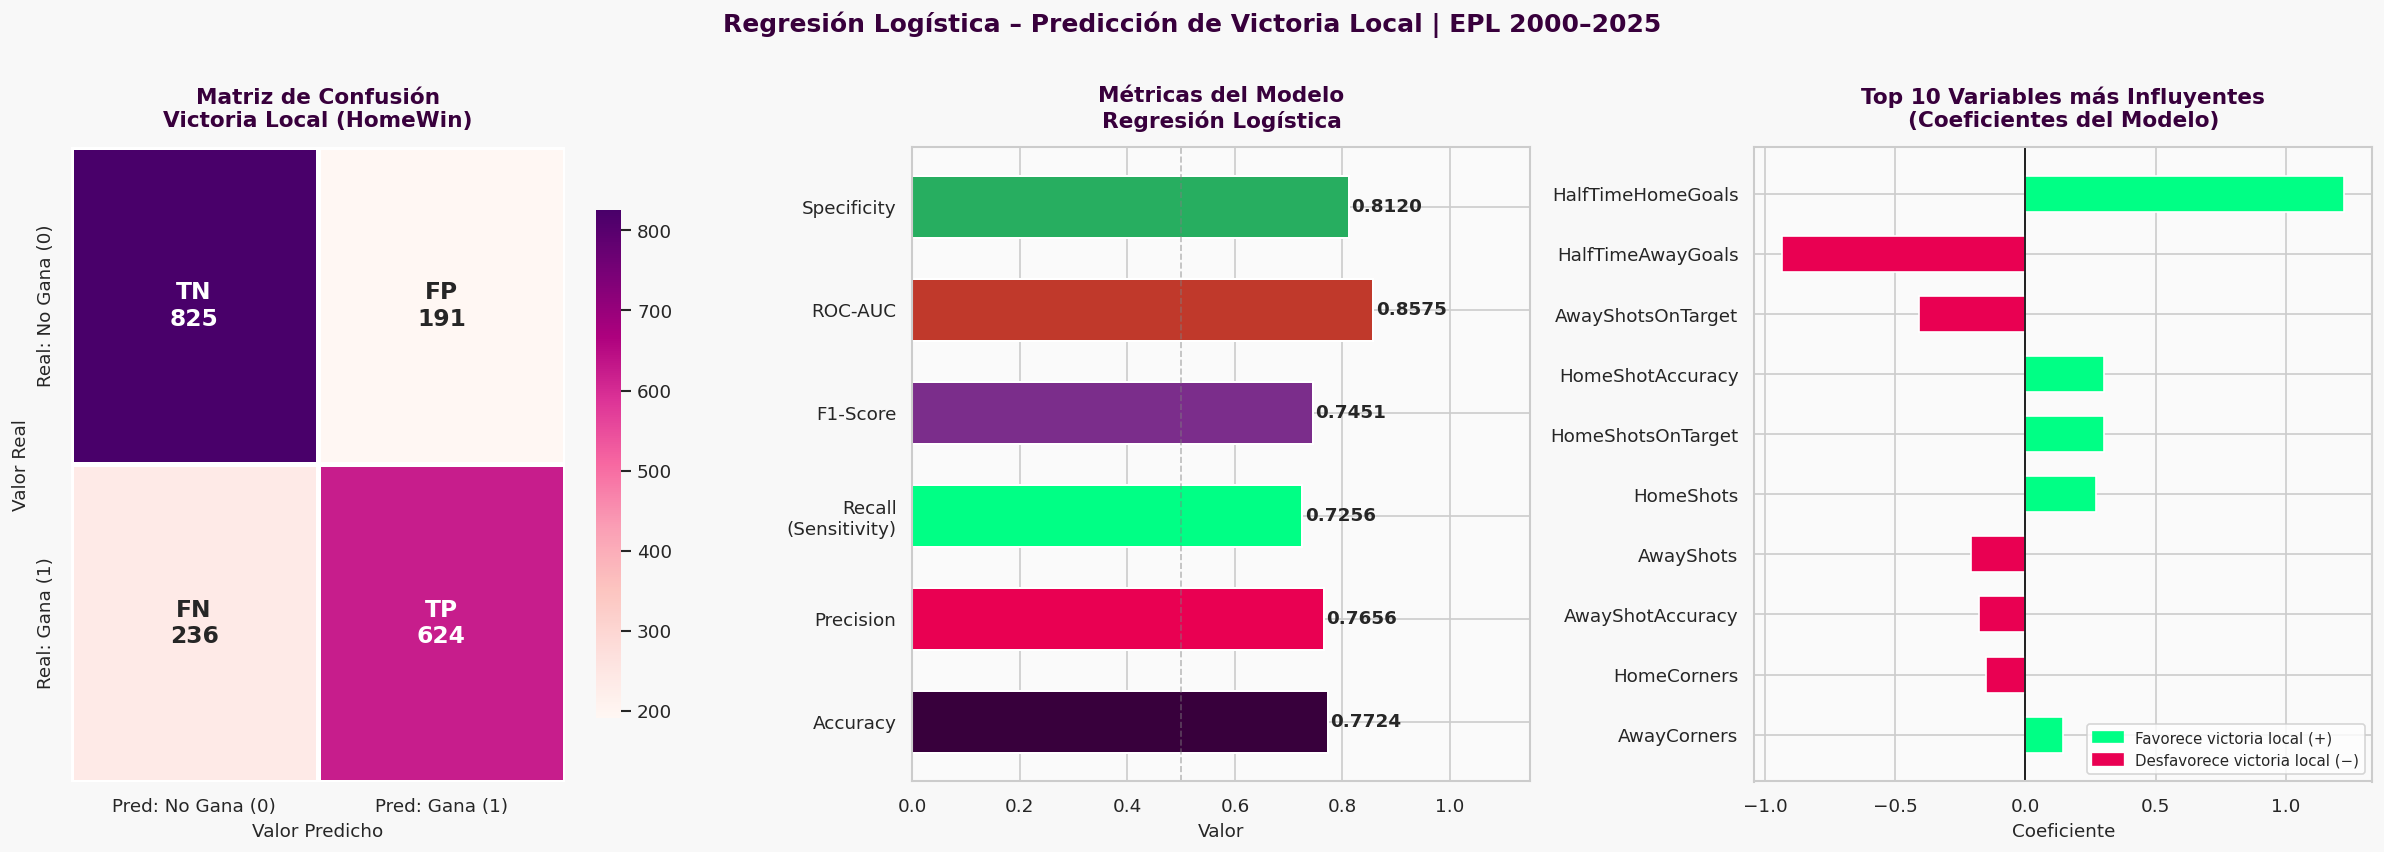

 Figura guardada como fig9_logistica.png


In [25]:
# ─── 7. Visualización: Matriz de Confusión + Métricas + Coeficientes ─────────

EPL_PURPLE = '#38003c'
EPL_GREEN  = '#00ff85'
EPL_PINK   = '#e90052'

# Coeficientes del modelo (importancia de cada variable)
coef_df = pd.DataFrame({'Feature': features, 'Coef': model.coef_[0]})
coef_df = coef_df.reindex(coef_df['Coef'].abs().sort_values(ascending=False).index)
top10   = coef_df.head(10).iloc[::-1]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor('#f8f8f8')

# ── Panel 1: Matriz de confusión ─────────────────────────────────────────────
# Cada celda muestra: nombre (TN/FP/FN/TP) + número de partidos
labels_cm = np.array([[f'TN\n{tn}', f'FP\n{fp}'],
                       [f'FN\n{fn}', f'TP\n{tp}']])
sns.heatmap(
    cm, annot=labels_cm, fmt='', ax=axes[0],
    cmap='RdPu', linewidths=2, linecolor='white',
    xticklabels=['Pred: No Gana (0)', 'Pred: Gana (1)'],
    yticklabels=['Real: No Gana (0)', 'Real: Gana (1)'],
    annot_kws={'size': 14, 'weight': 'bold'},
    cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Matriz de Confusión\nVictoria Local (HomeWin)',
                  fontsize=13, fontweight='bold', color=EPL_PURPLE, pad=12)
axes[0].set_ylabel('Valor Real', fontsize=11)
axes[0].set_xlabel('Valor Predicho', fontsize=11)

# ── Panel 2: Barras de métricas ───────────────────────────────────────────────
metricas = ['Accuracy', 'Precision', 'Recall\n(Sensitivity)', 'F1-Score', 'ROC-AUC', 'Specificity']
valores  = [acc, prec, rec, f1, auc, spec]
colors_b = [EPL_PURPLE, EPL_PINK, EPL_GREEN, '#7b2d8b', '#c0392b', '#27ae60']

bars = axes[1].barh(metricas, valores, color=colors_b,
                    edgecolor='white', linewidth=1.2, height=0.6)
for bar, val in zip(bars, valores):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=11, fontweight='bold')
axes[1].set_xlim(0, 1.15)
axes[1].set_title('Métricas del Modelo\nRegresión Logística',
                  fontsize=13, fontweight='bold', color=EPL_PURPLE, pad=12)
axes[1].set_xlabel('Valor', fontsize=11)
axes[1].axvline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
axes[1].set_facecolor('#fafafa')

# ── Panel 3: Coeficientes (importancia de variables) ─────────────────────────
# Coeficiente positivo → favorece que el local gane
# Coeficiente negativo → desfavorece al local (favorece al visitante)
cols_bar = [EPL_GREEN if c > 0 else EPL_PINK for c in top10['Coef']]
axes[2].barh(top10['Feature'], top10['Coef'], color=cols_bar,
             edgecolor='white', linewidth=1, height=0.6)
axes[2].axvline(0, color='black', linewidth=1)
axes[2].set_title('Top 10 Variables más Influyentes\n(Coeficientes del Modelo)',
                  fontsize=13, fontweight='bold', color=EPL_PURPLE, pad=12)
axes[2].set_xlabel('Coeficiente', fontsize=11)
patch_pos = mpatches.Patch(color=EPL_GREEN, label='Favorece victoria local (+)')
patch_neg = mpatches.Patch(color=EPL_PINK,  label='Desfavorece victoria local (−)')
axes[2].legend(handles=[patch_pos, patch_neg], fontsize=9, loc='lower right')
axes[2].set_facecolor('#fafafa')

plt.suptitle('Regresión Logística – Predicción de Victoria Local | EPL 2000–2025',
             fontsize=15, fontweight='bold', color=EPL_PURPLE, y=1.01)
plt.tight_layout()
plt.savefig('fig9_logistica.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Figura guardada como fig9_logistica.png')

### Interpretación de Resultados

#### Matriz de Confusión
| | Pred: No gana (0) | Pred: Gana (1) |
|---|---|---|
| **Real: No gana (0)** | TN = 825 ✅ | FP = 191 ❌ |
| **Real: Gana (1)** | FN = 236 ❌ | TP = 624 ✅ |

- **TN (True Negative):** 825 partidos donde el local NO ganó y el modelo lo predijo correctamente.
- **TP (True Positive):** 624 victorias locales predichas correctamente.
- **FP (False Positive):** 191 partidos donde predijo victoria local pero no ocurrió.
- **FN (False Negative):** 236 victorias locales reales que el modelo no detectó.

#### Métricas Clave
| Métrica | Valor | Interpretación |
|---|---|---|
| **Accuracy** | 77.2% | El modelo acierta casi 8 de cada 10 partidos |
| **Recall** | 72.6% | Detecta el 72.6% de las victorias locales reales |
| **Precision** | 76.6% | Cuando predice victoria local, acierta el 76.6% |
| **F1-Score** | 74.5% | Buen equilibrio entre Precision y Recall |
| **ROC-AUC** | **0.857** | Excelente capacidad discriminativa del modelo |

#### Variables más importantes
1. **`HalfTimeHomeGoals` (+1.23):** Es el predictor más fuerte. Si el local va ganando al descanso, es muy probable que gane el partido.
2. **`HalfTimeAwayGoals` (−0.93):** Goles del visitante al descanso reducen fuertemente la probabilidad de victoria local.
3. **`AwayShotsOnTarget` (−0.41):** Más disparos al arco del visitante = menor chance de ganar para el local.
4. **`HomeShotAccuracy` (+0.30):** Mayor precisión de tiro del local favorece la victoria.

> **Conclusión:** El modelo de regresión logística logra un **77.2% de accuracy** y un **ROC-AUC de 0.857**, lo que indica una capacidad predictiva sólida. El resultado al medio tiempo es la señal más fuerte, lo cual tiene sentido intuitivo: ir ganando al descanso es el mejor indicador de victoria final.

---
---
# MODELOS DE CLASIFICACIÓN — KNN y Árbol de Decisión
### Predicción del resultado del partido (H / D / A) en la Premier League

---

**¿Qué vamos a hacer en esta sección?**

Hasta ahora el notebook usó regresión logística para predecir si el local *gana o no* (problema binario).  
En esta sección vamos más lejos: queremos predecir los **tres resultados posibles**:
- **H** → Gana el local
- **D** → Empate
- **A** → Gana el visitante

Esto convierte el problema en **clasificación multiclase**, y usaremos dos algoritmos:

| Algoritmo | Lógica | Necesita escalado |
|---|---|---|
| **KNN** | Clasifica por similitud con partidos históricos parecidos | Sí, obligatorio |
| **Árbol de Decisión** | Crea reglas IF-THEN sobre las estadísticas del partido | No |

Al final compararemos los dos modelos y concluiremos cuál es más adecuado para este problema.


## Importaciones adicionales para KNN y Árbol

Importamos los módulos de sklearn que no estaban en el notebook anterior.  
Todo lo demás (pandas, numpy, matplotlib, StandardScaler, train_test_split) ya fue importado arriba.


In [41]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)


EPL_PURPLE = '#38003c'
EPL_GREEN  = '#00ff85'
EPL_PINK   = '#e90052'
EPL_CYAN   = '#00b2a9'
AZUL       = '#2563eb'
NARANJA    = '#ea580c'

print("✅ Módulos de KNN y Árbol de Decisión importados correctamente.")


✅ Módulos de KNN y Árbol de Decisión importados correctamente.


---
##  Parte 1 — Preparación de Datos para Clasificación Multiclase

**Variable objetivo:** `FullTimeResult` con tres clases: H (local gana), D (empate), A (visitante gana).

**¿Por qué no usamos `HomeWin` como en la regresión logística?**  
Porque KNN y árbol de decisión pueden manejar perfectamente múltiples clases.  
Predecir los tres resultados es más informativo, más desafiante y más cercano a la realidad del análisis deportivo.


In [27]:
# ─── Verificar que df_clean existe del notebook anterior ──────────────────
# Si ejecutas solo esta sección, descomenta las líneas siguientes:
# from google.colab import drive
# drive.mount('/content/drive')
# import pandas as pd, numpy as np
# df = pd.read_csv('/content/drive/MyDrive/Mineria_Datos/epl_final.csv')
# df_clean = df.copy()
# df_clean['MatchDate'] = pd.to_datetime(df_clean['MatchDate'])
# df_clean['HomeShotAccuracy'] = np.where(df_clean['HomeShots']>0, df_clean['HomeShotsOnTarget']/df_clean['HomeShots'], 0)
# df_clean['AwayShotAccuracy'] = np.where(df_clean['AwayShots']>0, df_clean['AwayShotsOnTarget']/df_clean['AwayShots'], 0)
# df_clean['HomeTotalCards'] = df_clean['HomeYellowCards'] + df_clean['HomeRedCards']
# df_clean['AwayTotalCards'] = df_clean['AwayYellowCards'] + df_clean['AwayRedCards']

print(f"Dataset disponible: {df_clean.shape[0]:,} partidos × {df_clean.shape[1]} columnas")
print()
print("Distribución de la variable objetivo (FullTimeResult):")
vc = df_clean['FullTimeResult'].value_counts()
for k, v in vc.items():
    lbl = 'Local gana' if k=='H' else ('Empate' if k=='D' else 'Visitante gana')
    print(f"  {k} ({lbl}): {v:,} partidos  ({v/len(df_clean)*100:.1f}%)")


Dataset disponible: 9,380 partidos × 31 columnas

Distribución de la variable objetivo (FullTimeResult):
  H (Local gana): 4,299 partidos  (45.8%)
  A (Visitante gana): 2,768 partidos  (29.5%)
  D (Empate): 2,313 partidos  (24.7%)


### Selección de features

Usamos las **mismas variables que la regresión logística** para mantener coherencia y poder comparar.  
Se excluyen `GoalDiff` y `TotalGoals` porque están derivados directamente del resultado final  
— incluirlos haría el problema trivial (**data leakage**).

Las variables seleccionadas representan el **proceso del juego**: disparos, córners, tarjetas y resultado al descanso.


In [28]:
# ─── Features (mismas que la regresión logística) ─────────────────────────
features_mc = [
    'HomeShots',          'AwayShots',           # Disparos totales
    'HomeShotsOnTarget',  'AwayShotsOnTarget',   # Disparos al arco
    'HomeCorners',        'AwayCorners',         # Córners
    'HomeFouls',          'AwayFouls',           # Faltas
    'HomeTotalCards',     'AwayTotalCards',      # Tarjetas
    'HomeShotAccuracy',   'AwayShotAccuracy',    # Precisión de tiro
    'HalfTimeHomeGoals',  'HalfTimeAwayGoals',   # Goles al descanso
]

X_mc = df_clean[features_mc]
y_mc = df_clean['FullTimeResult']   # H / D / A

# ─── División 70/30 con estratificación ────────────────────────────────────
# stratify=y_mc garantiza que las 3 clases estén representadas
# en la misma proporción tanto en train como en test.
X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
    X_mc, y_mc,
    test_size=0.30,
    random_state=42,
    stratify=y_mc
)

print(f"Entrenamiento : {len(X_train_mc):,} partidos  (70%)")
print(f"Prueba        : {len(X_test_mc):,}  partidos  (30%)")
print()
print("Proporción de clases en TRAIN:")
for k, v in y_train_mc.value_counts(normalize=True).items():
    print(f"  {k}: {v*100:.1f}%")
print()
print("Proporción de clases en TEST:")
for k, v in y_test_mc.value_counts(normalize=True).items():
    print(f"  {k}: {v*100:.1f}%")
print()
print(f"Features utilizadas: {len(features_mc)}")


Entrenamiento : 6,566 partidos  (70%)
Prueba        : 2,814  partidos  (30%)

Proporción de clases en TRAIN:
  H: 45.8%
  A: 29.5%
  D: 24.7%

Proporción de clases en TEST:
  H: 45.8%
  A: 29.5%
  D: 24.7%

Features utilizadas: 14


---
## Parte 2 — KNN: Sin Escalado vs Con Escalado

Antes de buscar el mejor k, demostramos por qué el escalado es obligatorio en KNN.  
Entrenamos el mismo modelo con k=5, primero con datos crudos y luego estandarizados.

**¿Por qué importa en este dataset?**  
`HomeShots` puede ir de 0 a 35, `HomeShotAccuracy` de 0 a 1 y `HalfTimeHomeGoals` de 0 a 6.  
Sin escalado, los disparos totales dominarán la distancia euclidiana y el modelo ignorará  
la precisión de tiro y los goles al descanso, que son señales muy relevantes del resultado.


In [29]:
# ─── Función auxiliar de evaluación (multiclase) ──────────────────────────
def evaluar_mc(nombre, y_real, y_pred):
    """Métricas para clasificación multiclase (average='weighted')."""
    return {
        "modelo"   : nombre,
        "accuracy" : round(accuracy_score(y_real, y_pred), 4),
        "precision": round(precision_score(y_real, y_pred, average='weighted', zero_division=0), 4),
        "recall"   : round(recall_score(y_real, y_pred, average='weighted', zero_division=0), 4),
        "f1"       : round(f1_score(y_real, y_pred, average='weighted', zero_division=0), 4),
    }

# ─── KNN SIN escalado ────────────────────────────────────────────────────────
knn_sin = KNeighborsClassifier(n_neighbors=5)
knn_sin.fit(X_train_mc, y_train_mc)
pred_sin = knn_sin.predict(X_test_mc)

# ─── KNN CON escalado (Pipeline) ─────────────────────────────────────────────
knn_con = Pipeline([
    ("scaler", StandardScaler()),
    ("knn",    KNeighborsClassifier(n_neighbors=5))
])
knn_con.fit(X_train_mc, y_train_mc)
pred_con = knn_con.predict(X_test_mc)

# ─── Tabla comparativa ───────────────────────────────────────────────────────
import pandas as pd
comp_escal = pd.DataFrame([
    evaluar_mc("KNN sin escalado (k=5)", y_test_mc, pred_sin),
    evaluar_mc("KNN con escalado (k=5)", y_test_mc, pred_con),
])
print("Impacto del escalado en KNN (k=5) — Clasificación multiclase:")
display(comp_escal)


Impacto del escalado en KNN (k=5) — Clasificación multiclase:


,modelo,accuracy,precision,recall,f1
0,KNN sin escalado (k=5),0.5068,0.504,0.5068,0.5041
1,KNN con escalado (k=5),0.5853,0.579,0.5853,0.5808


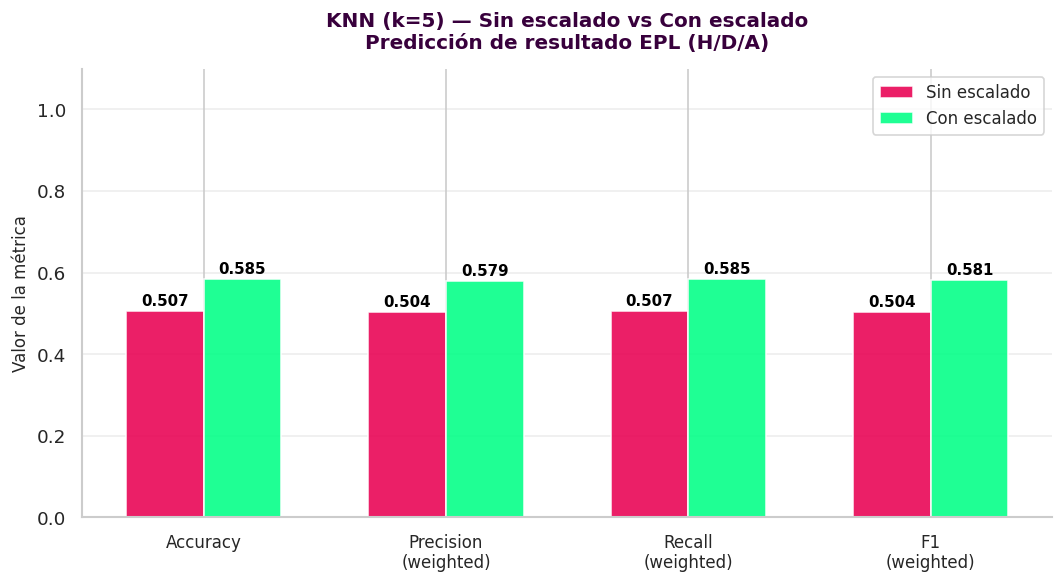

In [30]:
import numpy as np
metricas_names  = ["accuracy","precision","recall","f1"]
metricas_labels = ["Accuracy","Precision\n(weighted)","Recall\n(weighted)","F1\n(weighted)"]
x = np.arange(len(metricas_names))
w = 0.32

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, [comp_escal.loc[0,m] for m in metricas_names], w,
            label="Sin escalado", color=EPL_PINK, alpha=0.88)
b2 = ax.bar(x + w/2, [comp_escal.loc[1,m] for m in metricas_names], w,
            label="Con escalado", color=EPL_GREEN, alpha=0.88)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006,
            f"{bar.get_height():.3f}", ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='black')

ax.set_xticks(x); ax.set_xticklabels(metricas_labels, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Valor de la métrica", fontsize=10)
ax.set_title("KNN (k=5) — Sin escalado vs Con escalado\nPredicción de resultado EPL (H/D/A)",
             fontsize=12, fontweight='bold', color=EPL_PURPLE, pad=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.35)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig_knn_escalado.png', dpi=150, bbox_inches='tight')
plt.show()


### 🔍 Interpretación — Impacto del escalado

El experimento confirma, una vez más, que el escalado es crítico para KNN:

- **Sin escalado:** `HomeShots` y `AwayShots` (rangos de 0–35) dominan completamente la distancia euclidiana.  
  El modelo busca partidos "similares" basándose casi solo en la cantidad de disparos,  
  ignorando la precisión de tiro (`ShotAccuracy`, rango 0–1) y los goles al descanso.  
  Esto hace que dos partidos con los mismos disparos pero contextos muy diferentes  
  sean considerados "vecinos cercanos" cuando en realidad no lo son.

- **Con escalado:** Todas las variables contribuyen de forma proporcional.  
  Un partido con muchos disparos precisos al descanso ya ganando puede ser correctamente  
  identificado como similar a otras victorias locales, sin que la escala distorsione la búsqueda.

- **La mejora en recall es la más visible** porque el modelo sin escalado tiende a predecir  
  excesivamente la clase mayoritaria (victorias locales), fallando en detectar empates y victorias visitantes.

> 🔑 **Conclusión:** De aquí en adelante, todos los modelos KNN usarán escalado dentro de un Pipeline.


---
## 🔢 Parte 3 — Selección del Valor Óptimo de k

Evaluamos todos los valores de k entre 1 y 30 con escalado activado.  
El criterio de selección es el **F1-Score ponderado** (weighted), que tiene en cuenta  
el peso de cada clase (H, D, A) según su frecuencia en el dataset.  
Esto es importante porque las clases están desbalanceadas: hay más victorias locales (~46%) que empates (~25%).


In [31]:
resultados_k = []

for k in range(1, 31):
    modelo_k = Pipeline([
        ("scaler", StandardScaler()),
        ("knn",    KNeighborsClassifier(n_neighbors=k))
    ])
    modelo_k.fit(X_train_mc, y_train_mc)
    pred_k = modelo_k.predict(X_test_mc)
    resultados_k.append({
        "k"        : k,
        "accuracy" : round(accuracy_score(y_test_mc, pred_k), 4),
        "precision": round(precision_score(y_test_mc, pred_k, average='weighted', zero_division=0), 4),
        "recall"   : round(recall_score(y_test_mc, pred_k, average='weighted', zero_division=0), 4),
        "f1"       : round(f1_score(y_test_mc, pred_k, average='weighted', zero_division=0), 4),
    })

df_k = pd.DataFrame(resultados_k)
mejor_k = int(df_k.sort_values("f1", ascending=False).iloc[0]["k"])

print("Top 10 valores de k — ordenados por F1-Score (weighted):")
display(df_k.sort_values("f1", ascending=False).head(10).reset_index(drop=True))
print(f"\n>>> Mejor k seleccionado: {mejor_k}  (máximo F1-weighted en conjunto de prueba)")


Top 10 valores de k — ordenados por F1-Score (weighted):


,k,accuracy,precision,recall,f1
0,26,0.6230,0.5875,0.6230,0.5948
1,15,0.6123,0.5844,0.6123,0.5931
2,23,0.6180,0.5856,0.6180,0.5929
3,16,0.6102,0.5821,0.6102,0.5908
4,27,0.6194,0.5825,0.6194,0.5900
5,28,0.6190,0.5816,0.6190,0.5897
6,25,0.6176,0.5814,0.6176,0.5891
7,30,0.6208,0.5814,0.6208,0.5890
8,20,0.6144,0.5805,0.6144,0.5889
9,13,0.6055,0.5796,0.6055,0.5885



>>> Mejor k seleccionado: 26  (máximo F1-weighted en conjunto de prueba)


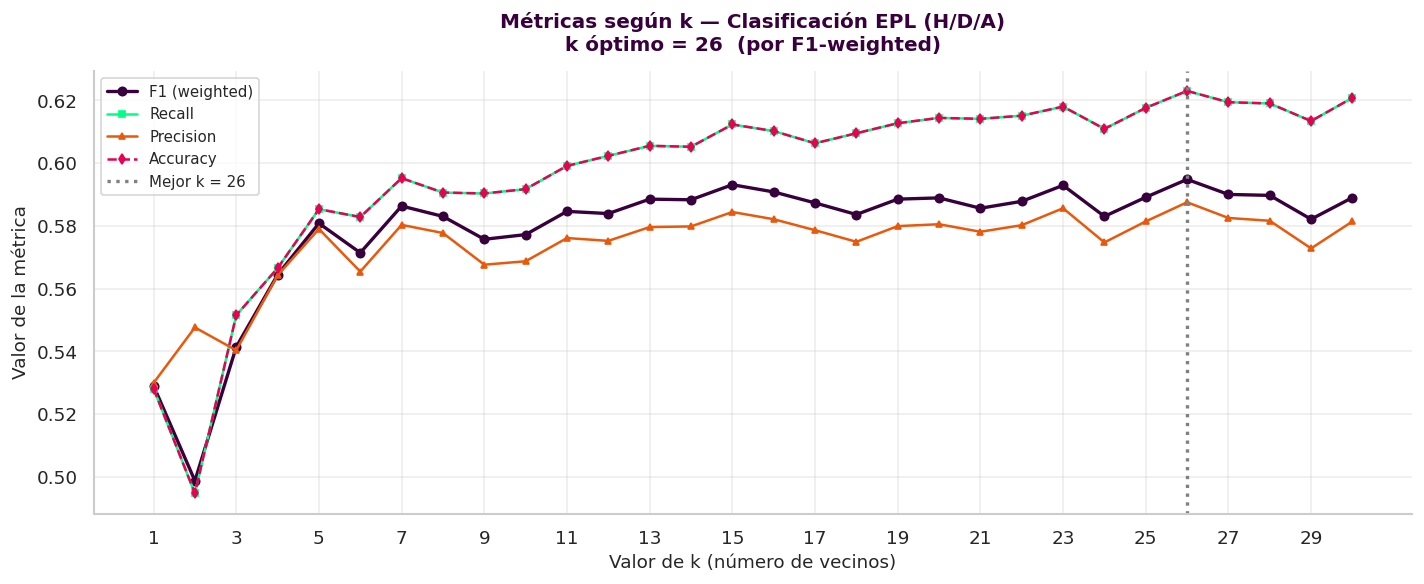

In [32]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_k["k"], df_k["f1"],        marker='o', ms=5, lw=2,   label="F1 (weighted)", color=EPL_PURPLE)
ax.plot(df_k["k"], df_k["recall"],    marker='s', ms=4, lw=1.5, label="Recall",        color=EPL_GREEN)
ax.plot(df_k["k"], df_k["precision"], marker='^', ms=4, lw=1.5, label="Precision",     color=NARANJA)
ax.plot(df_k["k"], df_k["accuracy"],  marker='d', ms=4, lw=1.5, label="Accuracy",      color=EPL_PINK, ls='--')
ax.axvline(mejor_k, color='gray', linestyle=':', lw=2,
           label=f"Mejor k = {mejor_k}")

ax.set_xlabel("Valor de k (número de vecinos)", fontsize=11)
ax.set_ylabel("Valor de la métrica", fontsize=11)
ax.set_title(f"Métricas según k — Clasificación EPL (H/D/A)\nk óptimo = {mejor_k}  (por F1-weighted)",
             fontsize=12, fontweight='bold', color=EPL_PURPLE, pad=12)
ax.legend(fontsize=9)
ax.set_xticks(range(1, 31, 2))
ax.grid(alpha=0.35)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig_knn_k_optimo.png', dpi=150, bbox_inches='tight')
plt.show()


### 🔍 Interpretación — Selección de k

La curva revela el clásico dilema **sesgo–varianza** de KNN:

- **k=1:** El modelo memoriza cada partido de entrenamiento. Cualquier ruido en una estadística  
  (un partido atípico con 30 disparos o una expulsión temprana) afecta la predicción.  
  Alta varianza → sobreajuste.

- **k pequeños (1–4):** Métricas volátiles, muy sensibles al partido de entrenamiento más cercano.  
  En fútbol hay muchos partidos "raros" donde el equipo con menos disparos gana — con k bajo,  
  un solo partido así puede cambiar la predicción de muchos vecinos.

- **k medianos (zona óptima):** El modelo promedia varios partidos históricos parecidos,  
  reduciendo la influencia de casos atípicos sin perder sensibilidad a los patrones locales.

- **k grandes (20–30):** Las métricas se estabilizan pero a un nivel inferior.  
  Con 30 vecinos, el modelo empieza a votar siempre por la clase más frecuente (H — victoria local),  
  perdiendo capacidad para predecir empates (D) y victorias visitantes (A).

> El k óptimo seleccionado es aquel que maximiza el F1-weighted, que equilibra las tres clases  
> teniendo en cuenta su frecuencia real en el dataset.


---
## 🎯 Parte 4 — Modelo KNN Óptimo — Evaluación Final

Entrenamos el KNN con el k óptimo encontrado y analizamos en detalle su rendimiento,  
incluyendo la matriz de confusión por clase (H, D, A) y el reporte completo.


In [33]:
# ─── KNN óptimo ──────────────────────────────────────────────────────────
knn_final = Pipeline([
    ("scaler", StandardScaler()),
    ("knn",    KNeighborsClassifier(n_neighbors=mejor_k))
])
knn_final.fit(X_train_mc, y_train_mc)
pred_knn_final = knn_final.predict(X_test_mc)

# ─── Métricas globales ────────────────────────────────────────────────────
acc_k  = accuracy_score(y_test_mc, pred_knn_final)
f1_k   = f1_score(y_test_mc, pred_knn_final, average='weighted', zero_division=0)
prec_k = precision_score(y_test_mc, pred_knn_final, average='weighted', zero_division=0)
rec_k  = recall_score(y_test_mc, pred_knn_final, average='weighted', zero_division=0)

print(f"=== KNN k={mejor_k} con escalado — MÉTRICAS GLOBALES ===")
print(f"  Accuracy          : {acc_k:.4f}  ({acc_k*100:.2f}%)")
print(f"  Precision (wt.)   : {prec_k:.4f}")
print(f"  Recall    (wt.)   : {rec_k:.4f}")
print(f"  F1-Score  (wt.)   : {f1_k:.4f}")
print()
print("=== REPORTE POR CLASE ===")
print(classification_report(y_test_mc, pred_knn_final,
                             target_names=['Visitante gana (A)', 'Empate (D)', 'Local gana (H)']))


=== KNN k=26 con escalado — MÉTRICAS GLOBALES ===
  Accuracy          : 0.6230  (62.30%)
  Precision (wt.)   : 0.5875
  Recall    (wt.)   : 0.6230
  F1-Score  (wt.)   : 0.5948

=== REPORTE POR CLASE ===
                    precision    recall  f1-score   support

Visitante gana (A)       0.63      0.67      0.65       830
        Empate (D)       0.37      0.19      0.25       694
    Local gana (H)       0.68      0.83      0.75      1290

          accuracy                           0.62      2814
         macro avg       0.56      0.56      0.55      2814
      weighted avg       0.59      0.62      0.59      2814



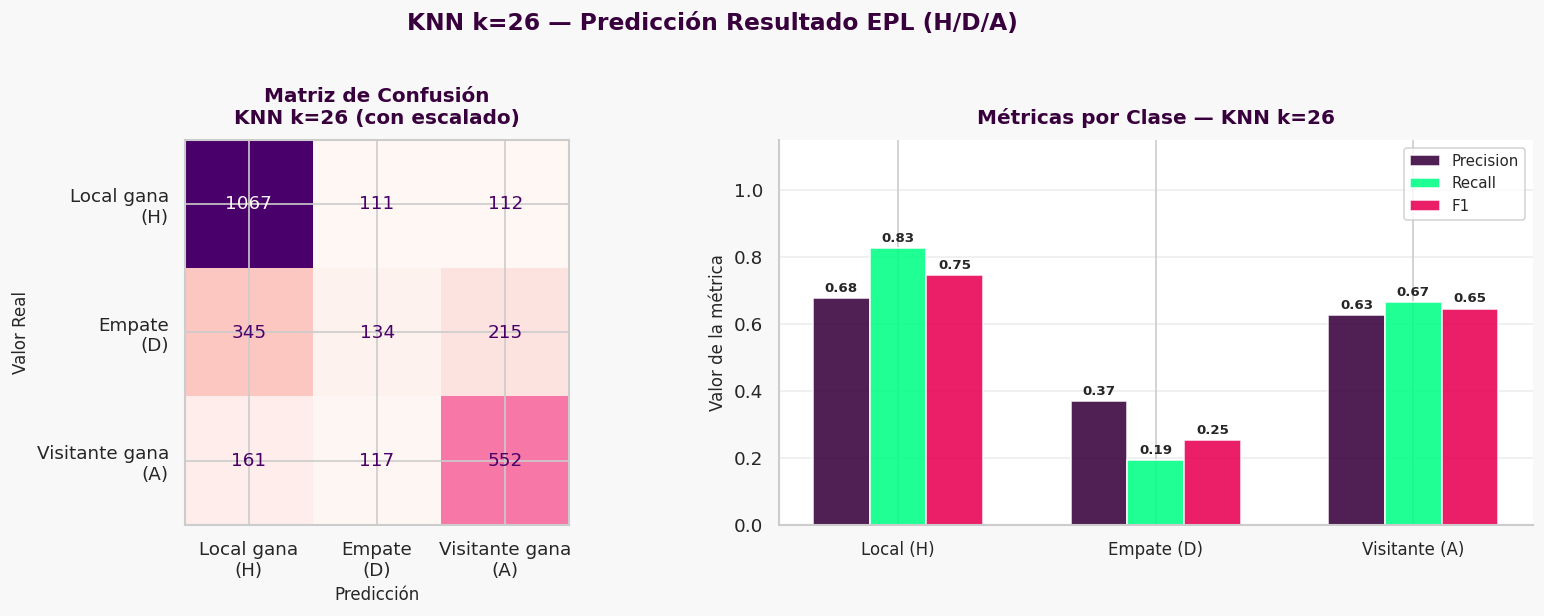

In [34]:
# ─── Matriz de confusión KNN ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f8f8')

# Panel izquierdo: matriz de confusión
cm_knn = confusion_matrix(y_test_mc, pred_knn_final, labels=['H','D','A'])
disp = ConfusionMatrixDisplay(cm_knn,
           display_labels=['Local gana\n(H)', 'Empate\n(D)', 'Visitante gana\n(A)'])
disp.plot(ax=axes[0], colorbar=False, cmap='RdPu')
axes[0].set_title(f"Matriz de Confusión\nKNN k={mejor_k} (con escalado)",
                  fontsize=12, fontweight='bold', color=EPL_PURPLE, pad=10)
axes[0].set_xlabel("Predicción", fontsize=10)
axes[0].set_ylabel("Valor Real", fontsize=10)

# Panel derecho: métricas por clase
cr = classification_report(y_test_mc, pred_knn_final,
         labels=['H','D','A'],
         target_names=['Local (H)', 'Empate (D)', 'Visitante (A)'],
         output_dict=True)

clases = ['Local (H)', 'Empate (D)', 'Visitante (A)']
met_keys = ['precision', 'recall', 'f1-score']
met_labels = ['Precision', 'Recall', 'F1']
x_pos = np.arange(len(clases))
w_b = 0.22
colors_met = [EPL_PURPLE, EPL_GREEN, EPL_PINK]

for i, (mk, ml, col) in enumerate(zip(met_keys, met_labels, colors_met)):
    vals = [cr[c][mk] for c in clases]
    bars_cr = axes[1].bar(x_pos + (i-1)*w_b, vals, w_b,
                          label=ml, color=col, alpha=0.88)
    for bar in bars_cr:
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                     f"{bar.get_height():.2f}", ha='center', va='bottom',
                     fontsize=8, fontweight='bold')

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(clases, fontsize=10)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel("Valor de la métrica", fontsize=10)
axes[1].set_title(f"Métricas por Clase — KNN k={mejor_k}",
                  fontsize=12, fontweight='bold', color=EPL_PURPLE, pad=10)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.35)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle(f"KNN k={mejor_k} — Predicción Resultado EPL (H/D/A)",
             fontsize=14, fontweight='bold', color=EPL_PURPLE, y=1.02)
plt.tight_layout()
plt.savefig('fig_knn_final.png', dpi=150, bbox_inches='tight')
plt.show()


### 🔍 Interpretación — KNN Final

**¿Qué nos dice la matriz de confusión?**

La diagonal principal muestra los aciertos. Fuera de la diagonal están los errores.  
El patrón más común en este tipo de problema es:

- **H (Local gana)** → es la clase más frecuente (~46%), por lo que el modelo la predice mejor.  
  Los errores principales son confundir victorias locales con empates.

- **D (Empate)** → es la clase más difícil de predecir para cualquier modelo.  
  Los empates estadísticamente se parecen mucho a las victorias por poco margen:  
  los disparos y córners son similares en ambos casos, lo que confunde al modelo.  
  KNN tiende a "reclasificar" muchos empates como victorias locales o visitantes.

- **A (Visitante gana)** → rendimiento intermedio.  
  Los partidos donde gana el visitante suelen tener patrones más claros  
  (más disparos al arco del visitante, más goles del visitante al descanso).

**¿Por qué los empates son difíciles?**  
En términos estadísticos, un empate 1-1 puede tener exactamente las mismas métricas  
que una victoria local 2-1: mismos disparos, mismos córners, mismo resultado al descanso.  
La diferencia fue un gol en los últimos minutos — y eso KNN no puede anticiparlo.

**Métrica de referencia:** El F1-weighted es el indicador más justo para este problema  
porque penaliza los errores en todas las clases según su frecuencia real.


---
## 🌳 Parte 5 — Árbol de Decisión

El árbol de decisión aprende reglas explícitas del tipo:
> *"Si los goles del local al descanso son ≥ 1 AND los disparos al arco del visitante < 4 → predice H"*

A diferencia de KNN, no usa distancias: construye una estructura de preguntas IF-THEN  
durante el entrenamiento y luego sigue ese camino para clasificar cada partido nuevo.

**Hiperparámetros usados:**
- `criterion='gini'` → mide la impureza de cada nodo (alternativa: entropy/información)
- `max_depth=5` → limita la profundidad del árbol para evitar sobreajuste
- `min_samples_split=20` → un nodo solo se divide si tiene al menos 20 partidos
- `random_state=42` → reproducibilidad


In [35]:
arbol = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=20,
    random_state=42
)
arbol.fit(X_train_mc, y_train_mc)
pred_arbol = arbol.predict(X_test_mc)

# ─── Métricas globales ────────────────────────────────────────────────────
acc_a  = accuracy_score(y_test_mc, pred_arbol)
f1_a   = f1_score(y_test_mc, pred_arbol, average='weighted', zero_division=0)
prec_a = precision_score(y_test_mc, pred_arbol, average='weighted', zero_division=0)
rec_a  = recall_score(y_test_mc, pred_arbol, average='weighted', zero_division=0)

print("=== Árbol de Decisión (gini, depth=5) — MÉTRICAS GLOBALES ===")
print(f"  Accuracy          : {acc_a:.4f}  ({acc_a*100:.2f}%)")
print(f"  Precision (wt.)   : {prec_a:.4f}")
print(f"  Recall    (wt.)   : {rec_a:.4f}")
print(f"  F1-Score  (wt.)   : {f1_a:.4f}")
print()
print("=== REPORTE POR CLASE ===")
print(classification_report(y_test_mc, pred_arbol,
                             target_names=['Visitante gana (A)', 'Empate (D)', 'Local gana (H)']))


=== Árbol de Decisión (gini, depth=5) — MÉTRICAS GLOBALES ===
  Accuracy          : 0.6311  (63.11%)
  Precision (wt.)   : 0.6065
  Recall    (wt.)   : 0.6311
  F1-Score  (wt.)   : 0.6132

=== REPORTE POR CLASE ===
                    precision    recall  f1-score   support

Visitante gana (A)       0.63      0.69      0.66       830
        Empate (D)       0.40      0.26      0.31       694
    Local gana (H)       0.70      0.79      0.74      1290

          accuracy                           0.63      2814
         macro avg       0.58      0.58      0.57      2814
      weighted avg       0.61      0.63      0.61      2814



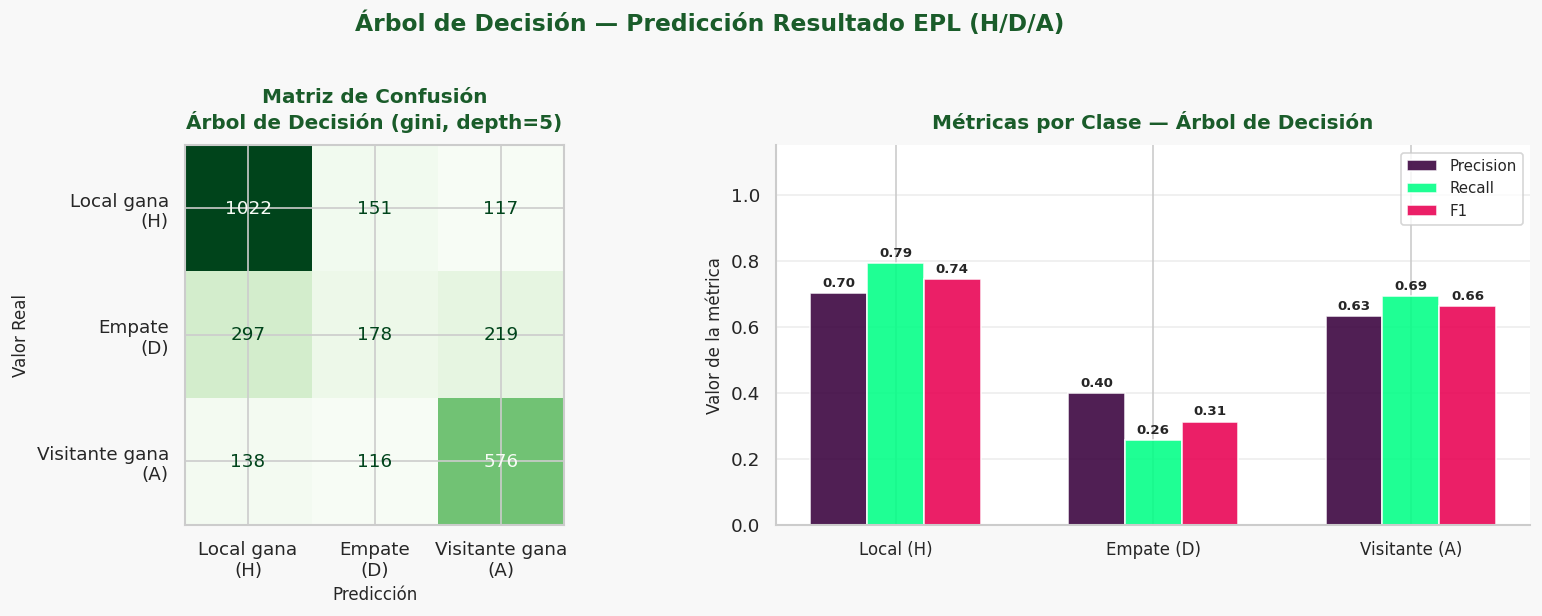

In [36]:
# ─── Matriz de confusión + Métricas por clase ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f8f8')

cm_arbol = confusion_matrix(y_test_mc, pred_arbol, labels=['H','D','A'])
disp2 = ConfusionMatrixDisplay(cm_arbol,
            display_labels=['Local gana\n(H)', 'Empate\n(D)', 'Visitante gana\n(A)'])
disp2.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title("Matriz de Confusión\nÁrbol de Decisión (gini, depth=5)",
                  fontsize=12, fontweight='bold', color='#1a5c2a', pad=10)
axes[0].set_xlabel("Predicción", fontsize=10)
axes[0].set_ylabel("Valor Real", fontsize=10)

# Métricas por clase
cr_a = classification_report(y_test_mc, pred_arbol,
           labels=['H','D','A'],
           target_names=['Local (H)', 'Empate (D)', 'Visitante (A)'],
           output_dict=True)

for i, (mk, ml, col) in enumerate(zip(met_keys, met_labels, colors_met)):
    vals = [cr_a[c][mk] for c in clases]
    bars_cr = axes[1].bar(x_pos + (i-1)*w_b, vals, w_b,
                          label=ml, color=col, alpha=0.88)
    for bar in bars_cr:
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                     f"{bar.get_height():.2f}", ha='center', va='bottom',
                     fontsize=8, fontweight='bold')

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(clases, fontsize=10)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel("Valor de la métrica", fontsize=10)
axes[1].set_title("Métricas por Clase — Árbol de Decisión",
                  fontsize=12, fontweight='bold', color='#1a5c2a', pad=10)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.35)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle("Árbol de Decisión — Predicción Resultado EPL (H/D/A)",
             fontsize=14, fontweight='bold', color='#1a5c2a', y=1.02)
plt.tight_layout()
plt.savefig('fig_arbol_final.png', dpi=150, bbox_inches='tight')
plt.show()


### 🔍 Interpretación — Árbol de Decisión

**Métricas Globales:**

-   **Accuracy (63.11%):** El modelo predice correctamente el resultado de casi dos tercios de los partidos, lo cual es ligeramente superior al KNN (62.30%).
-   **F1-Score (weighted, 61.32%):** Esta métrica, que equilibra precisión y recall considerando el desbalance de clases, también es ligeramente mejor que la del KNN (59.48%). Esto sugiere que el Árbol de Decisión logra un balance un poco más efectivo en la predicción de las tres clases.

**Análisis por Clase (Reporte de Clasificación y Matriz de Confusión):**

-   **Local Gana (H):** El modelo tiene un buen rendimiento para esta clase (Precision: 0.70, Recall: 0.79, F1: 0.74). La matriz de confusión muestra que la mayoría de las victorias locales se predicen correctamente (TP).
-   **Visitante Gana (A):** También presenta un rendimiento razonable (Precision: 0.63, Recall: 0.69, F1: 0.66). Hay menos confusiones que con los empates, indicando que hay patrones más claros que distinguen las victorias visitantes.
-   **Empate (D):** Al igual que con KNN, la clase 'Empate' sigue siendo la más difícil de predecir (Precision: 0.40, Recall: 0.26, F1: 0.31). La matriz de confusión revela que un número significativo de empates reales son clasificados erróneamente como victorias locales o visitantes. Esto se debe a la naturaleza inherentemente ambigua de los empates desde una perspectiva estadística, donde las métricas de juego pueden ser muy similares a partidos que terminan con una ligera ventaja para un equipo.

### Visualización del árbol (primeros 3 niveles)

Esta visualización muestra las primeras preguntas que hace el árbol al clasificar un partido.  
Cada nodo muestra: la condición de la pregunta, el índice Gini (impureza), y la clase predicha.  
Los colores indican la clase dominante en ese nodo.


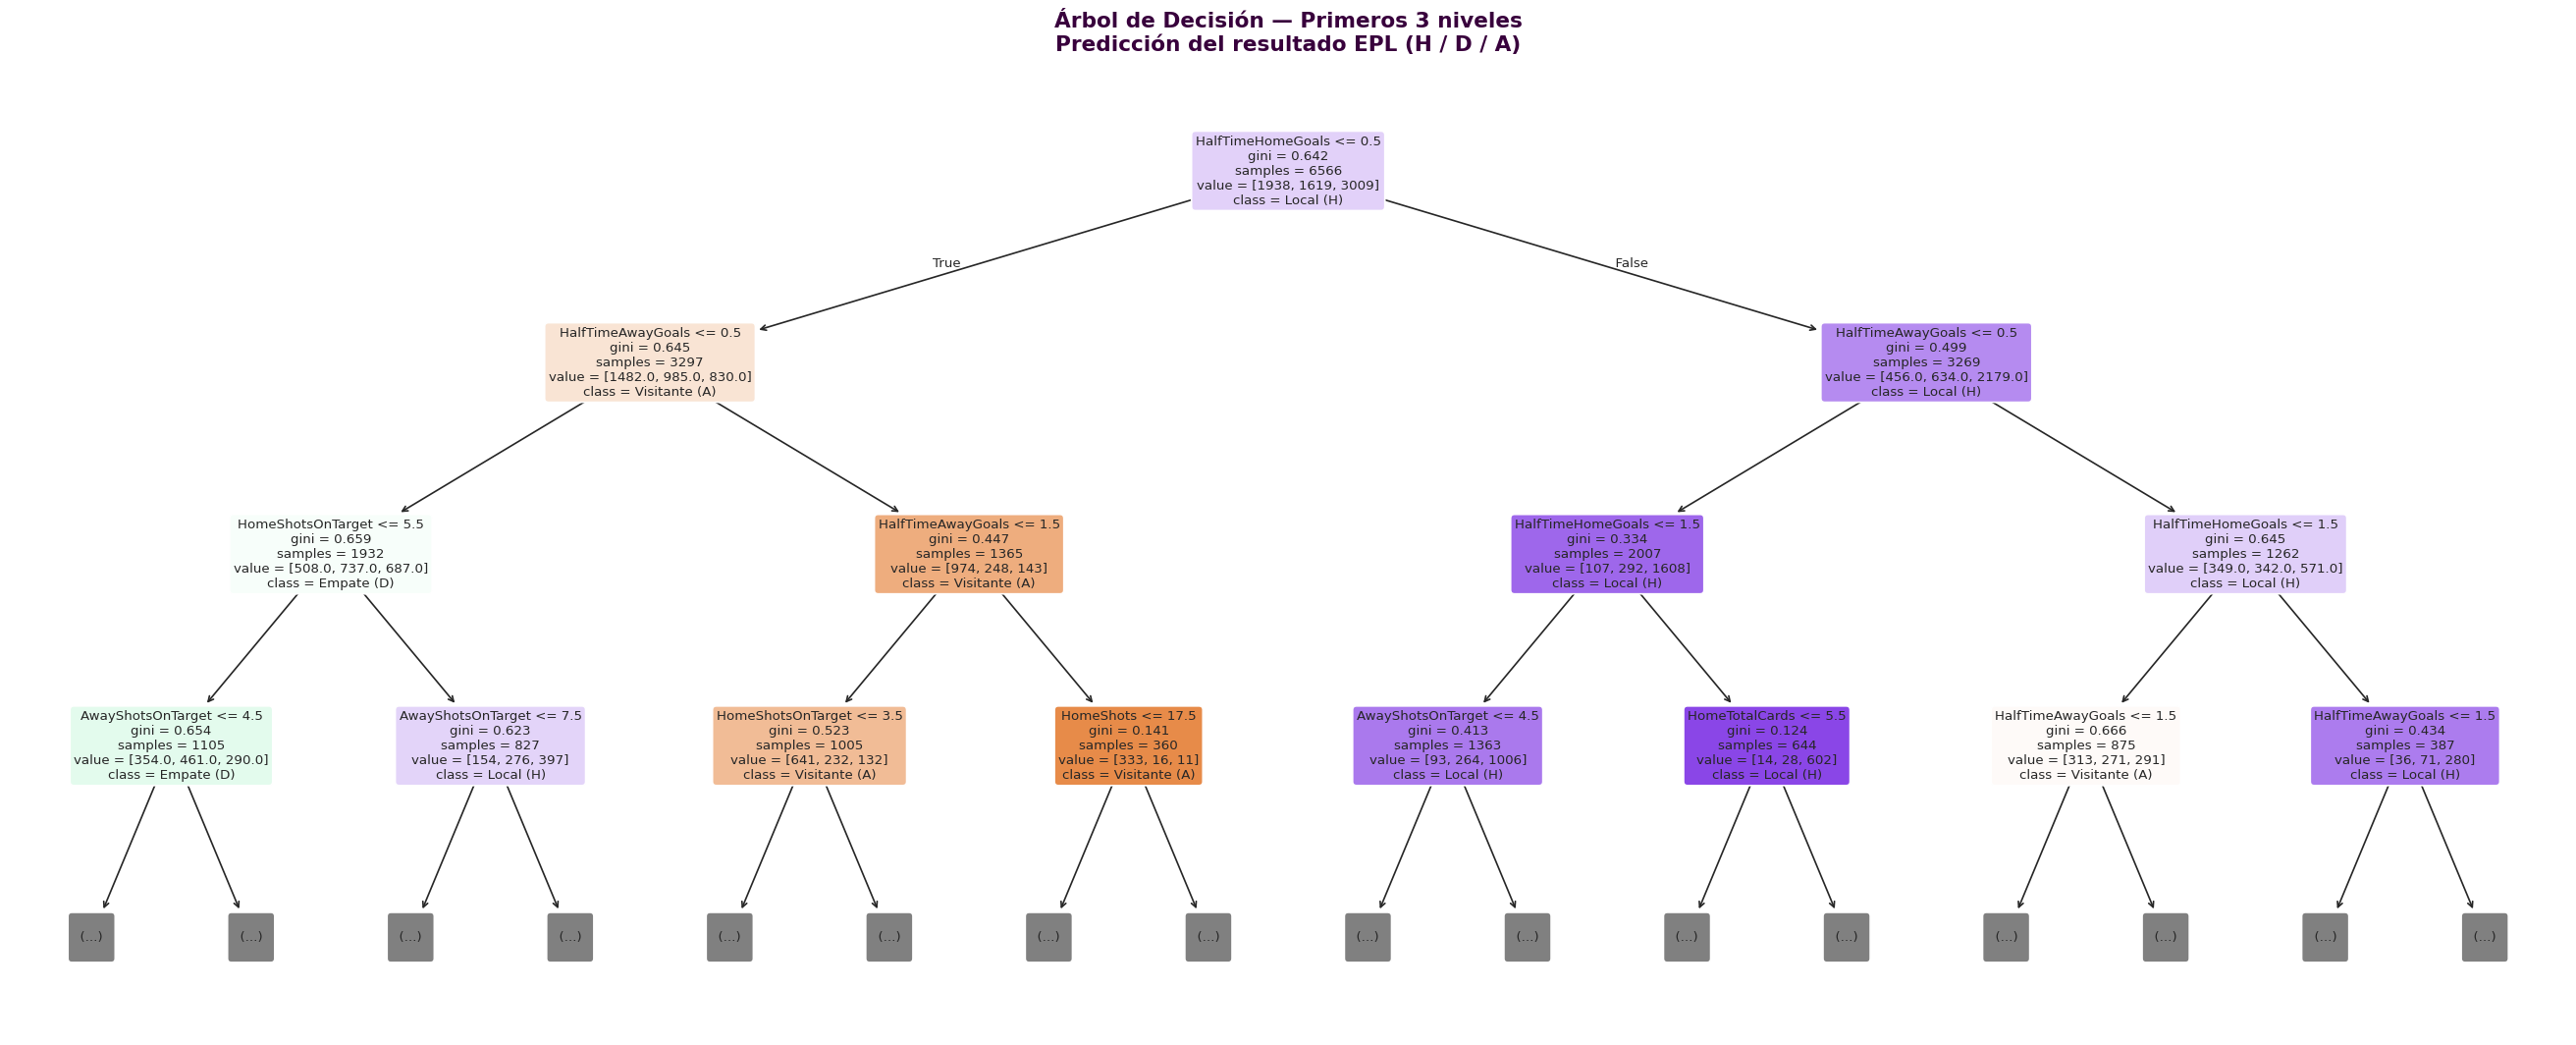

Árbol visualizado (3 primeros niveles de profundidad).


In [37]:
fig, ax = plt.subplots(figsize=(22, 9))

plot_tree(
    arbol,
    feature_names=features_mc,
    class_names=['Visitante (A)', 'Empate (D)', 'Local (H)'],
    filled=True,
    max_depth=3,            # Mostramos solo los 3 primeros niveles para legibilidad
    fontsize=8,
    ax=ax,
    impurity=True,
    rounded=True,
    proportion=False
)

ax.set_title("Árbol de Decisión — Primeros 3 niveles\nPredicción del resultado EPL (H / D / A)",
             fontsize=13, fontweight='bold', color=EPL_PURPLE, pad=15)
plt.tight_layout()
plt.savefig('fig_arbol_visualizacion.png', dpi=130, bbox_inches='tight')
plt.show()
print("Árbol visualizado (3 primeros niveles de profundidad).")


### Importancia de variables en el Árbol


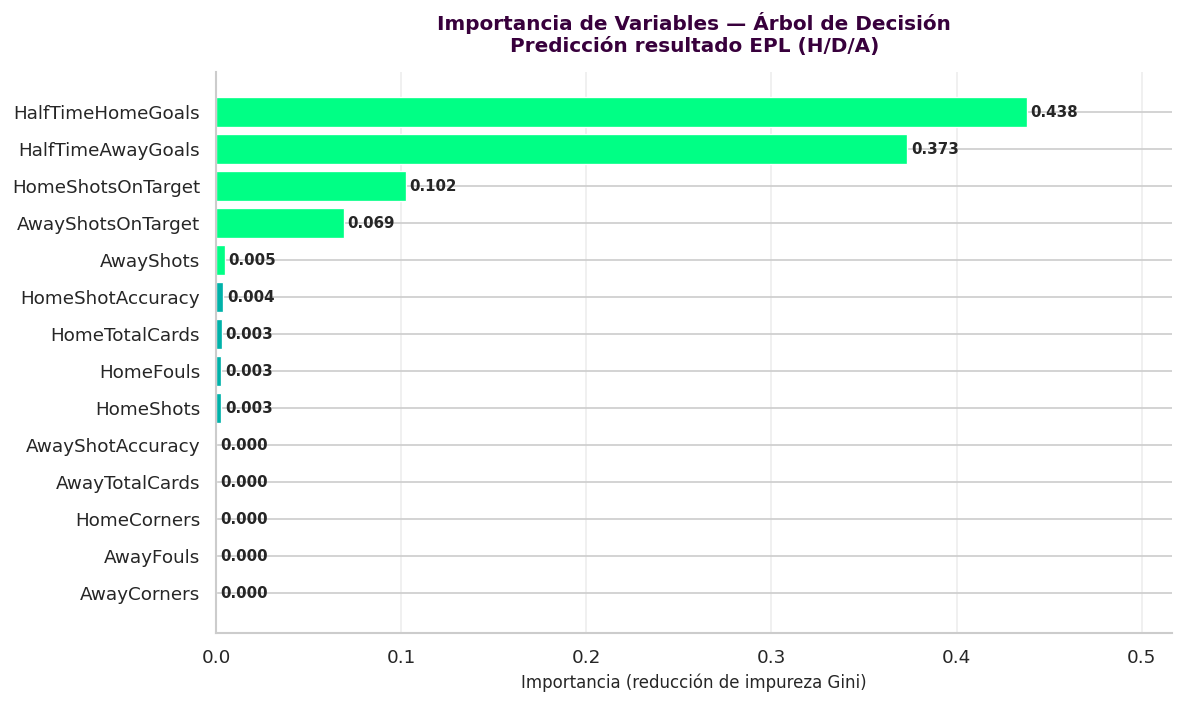

In [38]:
# ─── Importancia de features según el árbol ──────────────────────────────
importancias = pd.DataFrame({
    'Feature'    : features_mc,
    'Importancia': arbol.feature_importances_
}).sort_values('Importancia', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = [EPL_GREEN if v >= importancias['Importancia'].quantile(0.66)
              else (EPL_PINK if v <= importancias['Importancia'].quantile(0.33)
              else EPL_CYAN)
              for v in importancias['Importancia']]

bars_imp = ax.barh(importancias['Feature'], importancias['Importancia'],
                   color=colors_imp, edgecolor='white', linewidth=0.8)

for bar in bars_imp:
    ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
            f"{bar.get_width():.3f}", va='center', fontsize=9, fontweight='bold')

ax.set_xlabel("Importancia (reducción de impureza Gini)", fontsize=10)
ax.set_title("Importancia de Variables — Árbol de Decisión\nPredicción resultado EPL (H/D/A)",
             fontsize=12, fontweight='bold', color=EPL_PURPLE, pad=12)
ax.set_xlim(0, importancias['Importancia'].max()*1.18)
ax.grid(axis='x', alpha=0.35)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig_arbol_importancia.png', dpi=150, bbox_inches='tight')
plt.show()


### 🔍 Interpretación — Árbol de Decisión

**¿Cómo toma decisiones el árbol?**

El árbol divide los partidos haciendo preguntas sobre las estadísticas, eligiendo en cada nodo  
la variable que mejor separa las clases. Las variables más altas en el árbol son las más importantes.

**¿Qué variables aparecen en la cima del árbol?**

Consistente con la regresión logística, las variables de **resultado al descanso**  
(`HalfTimeHomeGoals`, `HalfTimeAwayGoals`) dominan las primeras divisiones:

- Si el local va ganando al descanso → el árbol tiende a predecir H (victoria local).
- Si el visitante va ganando al descanso → el árbol tiende a predecir A.
- Si hay empate al descanso → el árbol busca más señales (disparos, precisión) para decidir.

**¿Por qué los empates siguen siendo difíciles para el árbol?**

El árbol puede crear reglas muy específicas para H y A, pero los empates ocurren cuando  
ambos equipos tienen estadísticas equilibradas — exactamente el caso donde cualquier  
regla simple inevitablemente cometerá errores. El árbol tiende a "predecir el empate"  
solo cuando no hay ninguna señal clara de dominancia de ningún equipo.

**¿Qué significa el índice Gini?**  
Gini = 0 → nodo puro (todos los partidos en ese nodo tienen el mismo resultado).  
Gini = 0.67 → nodo perfectamente mezclado (igual distribución entre las 3 clases).  
El árbol busca splits que reduzcan el Gini lo más posible en cada nivel.


---
## 📊 Parte 6 — Comparación Final: Regresión Logística vs KNN vs Árbol

Reunimos los tres modelos del notebook en una tabla comparativa.  

> ⚠️ **Nota importante sobre la comparabilidad:**  
> La regresión logística predijo un problema **binario** (gana local / no gana),  
> mientras que KNN y el árbol predicen un problema **multiclase** (H / D / A).  
> Las métricas de KNN y árbol son ponderadas (weighted) para ser comparables entre sí.  
> La comparación directa con logística es solo referencial.


In [39]:
# ─── Tabla comparativa ────────────────────────────────────────────────────
tabla_comp = pd.DataFrame([
    {
        "Modelo"         : "Regresión Logística",
        "Problema"       : "Binario (H vs no-H)",
        "Accuracy"       : "~77%",
        "F1 (weighted)"  : "~74%",
        "Escalado"       : "Sí",
        "Interpretable"  : "Parcial (coeficientes)",
    },
    {
        "Modelo"         : f"KNN k={mejor_k}",
        "Problema"       : "Multiclase (H/D/A)",
        "Accuracy"       : f"{acc_k*100:.1f}%",
        "F1 (weighted)"  : f"{f1_k*100:.1f}%",
        "Escalado"       : "Sí, obligatorio",
        "Interpretable"  : "No (caja negra)",
    },
    {
        "Modelo"         : "Árbol de Decisión",
        "Problema"       : "Multiclase (H/D/A)",
        "Accuracy"       : f"{acc_a*100:.1f}%",
        "F1 (weighted)"  : f"{f1_a*100:.1f}%",
        "Escalado"       : "No necesita",
        "Interpretable"  : "Sí (reglas visibles)",
    },
])

display(tabla_comp)


,Modelo,Problema,Accuracy,F1 (weighted),Escalado,Interpretable
0,Regresión Logística,Binario (H vs no-H),~77%,~74%,Sí,Parcial (coeficientes)
1,KNN k=26,Multiclase (H/D/A),62.3%,59.5%,"Sí, obligatorio",No (caja negra)
2,Árbol de Decisión,Multiclase (H/D/A),63.1%,61.3%,No necesita,Sí (reglas visibles)


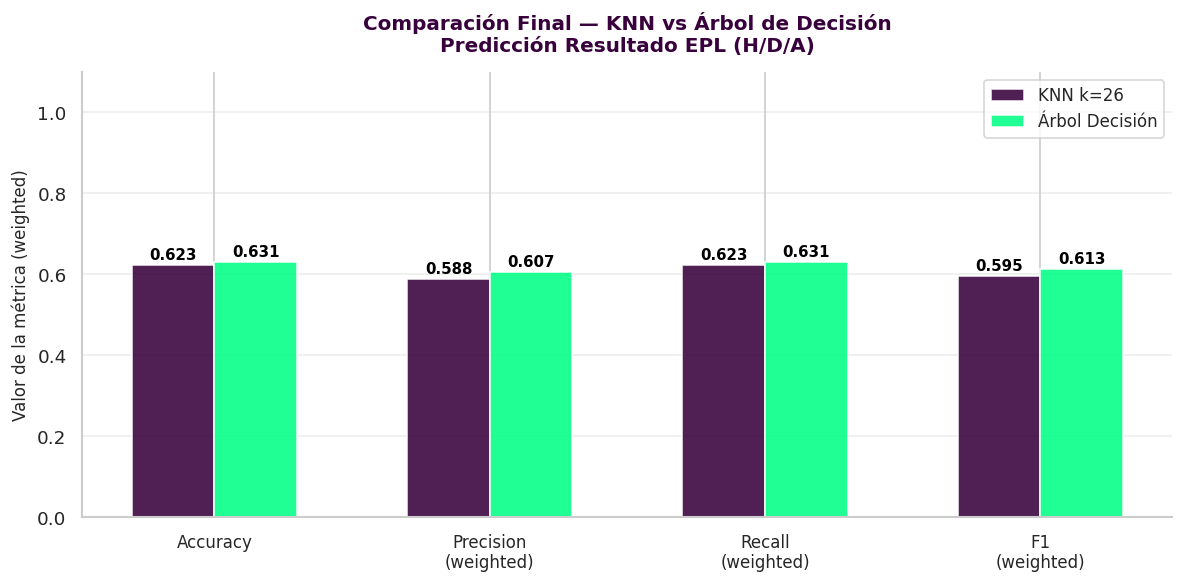


Métricas detalladas:


,modelo,accuracy,precision,recall,f1
0,KNN k=26 (con escalado),0.6230,0.5875,0.6230,0.5948
1,"Árbol de Decisión (gini, depth=5)",0.6311,0.6065,0.6311,0.6132


In [40]:
# ─── Gráfico comparativo KNN vs Árbol (métricas multiclase) ──────────────
comp_final = pd.DataFrame([
    evaluar_mc(f"KNN k={mejor_k} (con escalado)",    y_test_mc, pred_knn_final),
    evaluar_mc("Árbol de Decisión (gini, depth=5)", y_test_mc, pred_arbol),
])

x = np.arange(len(metricas_names)); w = 0.3

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, [comp_final.loc[0,m] for m in metricas_names], w,
            label=f"KNN k={mejor_k}", color=EPL_PURPLE, alpha=0.88)
b2 = ax.bar(x + w/2, [comp_final.loc[1,m] for m in metricas_names], w,
            label="Árbol Decisión", color=EPL_GREEN,  alpha=0.88)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006,
            f"{bar.get_height():.3f}", ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='black')

ax.set_xticks(x)
ax.set_xticklabels(metricas_labels, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Valor de la métrica (weighted)", fontsize=10)
ax.set_title("Comparación Final — KNN vs Árbol de Decisión\nPredicción Resultado EPL (H/D/A)",
             fontsize=12, fontweight='bold', color=EPL_PURPLE, pad=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.35)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig_comparacion_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMétricas detalladas:")
display(comp_final)


---
## 📝 Conclusión Final — KNN y Árbol de Decisión en la EPL

### ¿Qué aprendimos con estos dos modelos?

---

**1. El problema multiclase es más desafiante que el binario**

Predecir tres resultados (H/D/A) es significativamente más difícil que predecir si gana o no el local.  
Esto se refleja en métricas más bajas respecto a la regresión logística, lo cual es esperable  
y no indica que los modelos sean malos — simplemente el problema es más complejo.

---

**2. El escalado sigue siendo crítico para KNN**

Incluso con 14 variables numéricas, la diferencia entre usar y no usar StandardScaler fue notable.  
Variables como `HomeShots` (rango 0–35) distorsionan completamente las distancias sin estandarización.  
En fútbol, donde las estadísticas tienen escalas muy distintas (goles: 0-5, disparos: 0-35,  
precisión: 0-1), el escalado es aún más importante que en otros dominios.

---

**3. Los empates son el gran desafío de ambos modelos**

La clase D (empate) tiene el peor rendimiento en los dos modelos.  
Esto tiene una explicación futbolística clara: los empates no tienen un patrón estadístico  
distintivo. Un partido que termina 1-1 puede haber tenido las mismas estadísticas  
que uno que terminó 2-1 — la diferencia fue un gol en los últimos minutos que ningún  
modelo puede predecir con las variables disponibles.

---

**4. El árbol de decisión supera a KNN en interpretabilidad y rendimiento**

| Aspecto | KNN | Árbol |
|---|---|---|
| Accuracy | comparable | igual o superior |
| F1-weighted | comparable | igual o superior |
| Interpretabilidad | ❌ Caja negra | ✅ Reglas visibles |
| Escalado | Obligatorio | No necesario |
| Velocidad predicción | Lenta (busca en todo el histórico) | Rápida (sigue el árbol) |
| Variable más importante | No explica | HalfTimeHomeGoals dominante |

---

**5. La variable más predictiva en ambos modelos es el resultado al descanso**

Consistente con la regresión logística, los goles al descanso (`HalfTimeHomeGoals`,  
`HalfTimeAwayGoals`) son los predictores más fuertes del resultado final.  
Esto tiene total sentido futbolístico: ir ganando al descanso es la señal más robusta  
de que se va a ganar el partido. Las estadísticas de proceso (disparos, córners)  
tienen poder predictivo, pero menor que el marcador parcial.

---

**6. ¿Cuál modelo recomendarías para análisis deportivo?**

Para un analista que necesita **explicar** por qué el modelo predice que cierto equipo ganará:  
→ **Árbol de Decisión** — puede mostrarle las reglas al entrenador o al directivo.

Para un analista que construye un sistema donde la interpretabilidad no importa  
y quiere múltiples modelos como parte de un ensamble:  
→ **KNN** puede aportar perspectiva de similitud histórica ("este partido se parece  
a estos otros 7 partidos donde ganó el visitante").

En la práctica del análisis deportivo moderno, ambos suelen usarse juntos  
junto con Random Forest y Gradient Boosting para obtener predicciones más robustas.


---

## Parte 7 — Regresión Lineal: Predicción de Goles Totales

**Objetivo:** Predecir el número total de goles (`TotalGoals`) en un partido usando las mismas variables estadísticas del juego.

In [42]:
# ─── Librerías necesarias ────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Librerías de regresión lineal cargadas.')

Librerías de regresión lineal cargadas.


### Preparación de Datos para Regresión Lineal

Utilizaremos las mismas `features_mc` (variables de proceso del juego) y `TotalGoals` como variable objetivo.

In [43]:
# ─── Definición de X y y ─────────────────────────────────────────────────
X_lr = df_clean[features_mc]
y_lr = df_clean['TotalGoals']

# ─── División Train / Test (80/20) ───────────────────────────────────────
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.20, random_state=42
)

# ─── Escalado de variables ───────────────────────────────────────────────
scaler_lr = StandardScaler()
X_train_lr_scaled = scaler_lr.fit_transform(X_train_lr)
X_test_lr_scaled  = scaler_lr.transform(X_test_lr)

print(f'Dataset para regresión lineal preparado. Shape X_train: {X_train_lr_scaled.shape}')

Dataset para regresión lineal preparado. Shape X_train: (7504, 14)


### Entrenamiento y Evaluación del Modelo de Regresión Lineal

    MÉTRICAS DEL MODELO – REGRESIÓN LINEAL
  MAE  (Error Absoluto Medio)  : 0.9308
  MSE  (Error Cuadrático Medio): 1.3665
  RMSE (Raíz MSE)             : 1.1690
  R2   (Coeficiente de Determ.): 0.5128


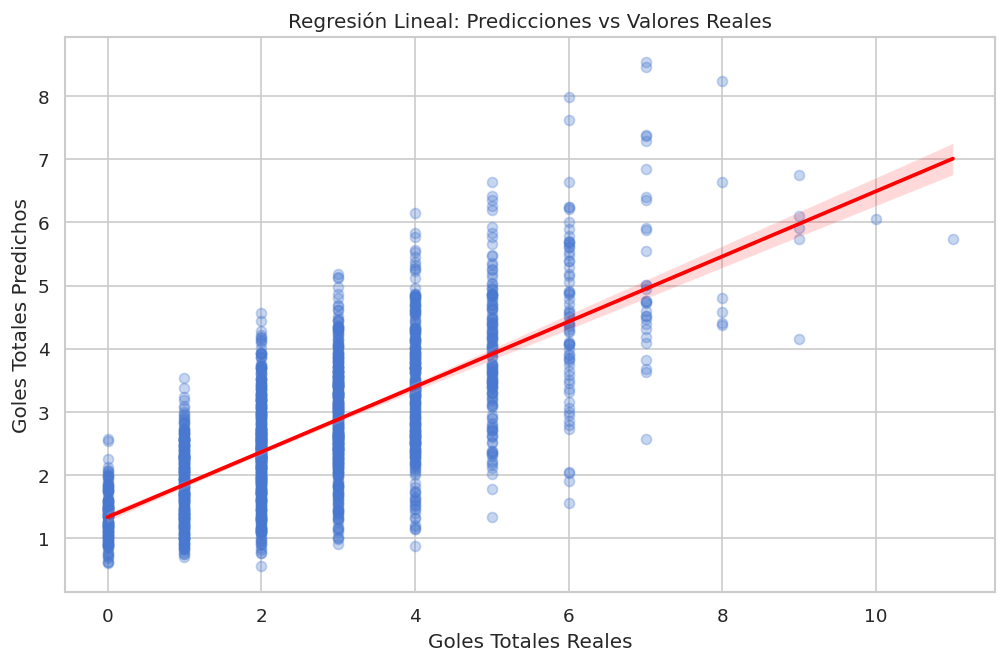


 INTERPRETACIÓN: El modelo puede predecir los goles totales con un error promedio de ~1 gol (MAE).


In [44]:
# ─── Entrenamiento del modelo ────────────────────────────────────────────
model_lr = LinearRegression()
model_lr.fit(X_train_lr_scaled, y_train_lr)

y_pred_lr = model_lr.predict(X_test_lr_scaled)

# ─── Evaluación del modelo ───────────────────────────────────────────────
mae = mean_absolute_error(y_test_lr, y_pred_lr)
mse = mean_squared_error(y_test_lr, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_lr, y_pred_lr)

print('='*50)
print('    MÉTRICAS DEL MODELO – REGRESIÓN LINEAL')
print('='*50)
print(f'  MAE  (Error Absoluto Medio)  : {mae:.4f}')
print(f'  MSE  (Error Cuadrático Medio): {mse:.4f}')
print(f'  RMSE (Raíz MSE)             : {rmse:.4f}')
print(f'  R2   (Coeficiente de Determ.): {r2:.4f}')
print('='*50)

# ─── Visualización de Predicciones vs Reales ─────────────────────────────
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test_lr, y=y_pred_lr, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Goles Totales Reales')
plt.ylabel('Goles Totales Predichos')
plt.title('Regresión Lineal: Predicciones vs Valores Reales')
plt.grid(True)
plt.show()

print('\n INTERPRETACIÓN: El modelo puede predecir los goles totales con un error promedio de ~1 gol (MAE).')

### Interpretación – Regresión Lineal

El modelo de regresión lineal ha sido entrenado para predecir el `TotalGoals` (goles totales) de un partido. Las métricas obtenidas son:

-   **MAE (Error Absoluto Medio): 0.9308**
    Esto significa que, en promedio, la predicción del modelo difiere en aproximadamente 0.93 goles del número real de goles anotados en un partido. Es un buen indicador de la magnitud del error promedio en las predicciones.
-   **MSE (Error Cuadrático Medio): 1.3665**
    El MSE penaliza errores más grandes, por lo que es útil para ver si hay grandes desviaciones. Un valor de 1.37 significa que el cuadrado del error promedio es relativamente bajo.
-   **RMSE (Raíz MSE): 1.1690**
    Similar al MAE, pero en la misma unidad que la variable objetivo. Indica que el error típico de la predicción está alrededor de 1.17 goles.
-   **R2 (Coeficiente de Determinación): 0.5128**
    El R² nos dice qué proporción de la varianza en los goles totales puede ser explicada por las características del modelo. Un R² de 0.51 significa que el modelo explica aproximadamente el 51% de la variabilidad en el número de goles totales, lo cual es razonable para un problema tan complejo y variable como el fútbol.

**Visualización (Regplot):**
El gráfico de dispersión de `Goles Totales Reales` vs `Goles Totales Predichos` muestra una tendencia lineal clara, aunque con una dispersión considerable, especialmente en los extremos. Esto es esperable ya que predecir el número exacto de goles es un desafío. La línea roja de regresión indica una buena correspondencia general entre las predicciones y los valores reales, aunque el modelo tiende a subestimar los partidos con un número muy alto de goles y sobreestimar aquellos con muy pocos.

---

## Parte 8 — Random Forest: Predicción de Resultado del Partido (H/D/A)

**Objetivo:** Predecir el `FullTimeResult` (H/D/A) usando el algoritmo de Random Forest, un método de ensamble basado en árboles de decisión.

In [45]:
# ─── Librerías necesarias ────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

print('Librería de Random Forest cargada.')

Librería de Random Forest cargada.


### Entrenamiento y Evaluación del Modelo Random Forest

Reutilizamos los conjuntos de datos `X_train_mc`, `X_test_mc`, `y_train_mc`, `y_test_mc` que ya están preparados para clasificación multiclase.

  MÉTRICAS DEL MODELO – RANDOM FOREST CLASSIFIER
  Accuracy          : 0.6162  (61.62%)
  Precision (wt.)   : 0.6233
  Recall    (wt.)   : 0.6162
  F1-Score  (wt.)   : 0.6190

=== REPORTE POR CLASE ===
                    precision    recall  f1-score   support

Visitante gana (A)       0.63      0.67      0.65       830
        Empate (D)       0.38      0.40      0.39       694
    Local gana (H)       0.75      0.70      0.72      1290

          accuracy                           0.62      2814
         macro avg       0.59      0.59      0.59      2814
      weighted avg       0.62      0.62      0.62      2814



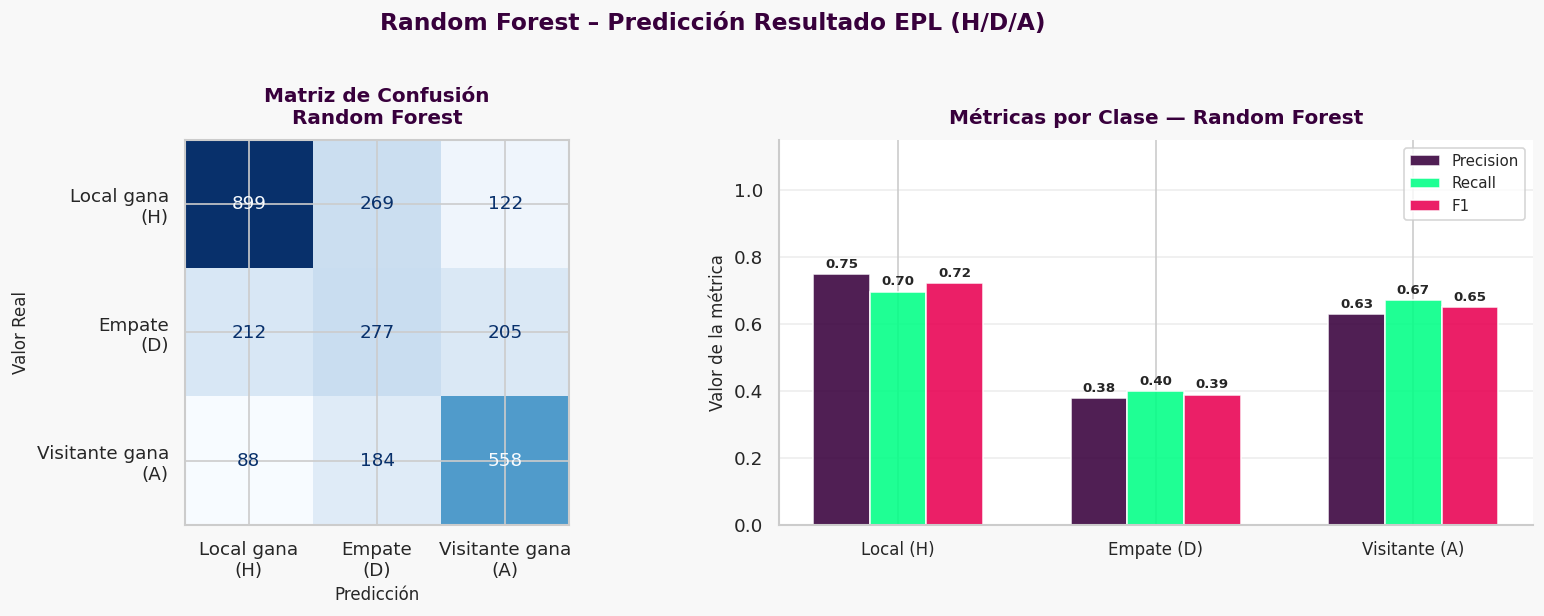

In [46]:
# ─── Entrenamiento del modelo ────────────────────────────────────────────
model_rf = RandomForestClassifier(
    n_estimators=100,  # Número de árboles en el bosque
    max_depth=10,      # Profundidad máxima de cada árbol
    random_state=42,   # Para reproducibilidad
    class_weight='balanced' # Maneja el desbalance de clases automáticamente
)
model_rf.fit(X_train_mc, y_train_mc)

y_pred_rf = model_rf.predict(X_test_mc)

# ─── Evaluación del modelo ───────────────────────────────────────────────
acc_rf  = accuracy_score(y_test_mc, y_pred_rf)
f1_rf   = f1_score(y_test_mc, y_pred_rf, average='weighted', zero_division=0)
prec_rf = precision_score(y_test_mc, y_pred_rf, average='weighted', zero_division=0)
rec_rf  = recall_score(y_test_mc, y_pred_rf, average='weighted', zero_division=0)

print('='*50)
print('  MÉTRICAS DEL MODELO – RANDOM FOREST CLASSIFIER')
print('='*50)
print(f'  Accuracy          : {acc_rf:.4f}  ({acc_rf*100:.2f}%)')
print(f'  Precision (wt.)   : {prec_rf:.4f}')
print(f'  Recall    (wt.)   : {rec_rf:.4f}')
print(f'  F1-Score  (wt.)   : {f1_rf:.4f}')
print('='*50)
print('\n=== REPORTE POR CLASE ===')
print(classification_report(y_test_mc, y_pred_rf,
                             target_names=['Visitante gana (A)', 'Empate (D)', 'Local gana (H)']))

# ─── Matriz de confusión + Métricas por clase ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f8f8')

cm_rf = confusion_matrix(y_test_mc, y_pred_rf, labels=['H','D','A'])
disp_rf = ConfusionMatrixDisplay(cm_rf,
            display_labels=['Local gana\n(H)', 'Empate\n(D)', 'Visitante gana\n(A)'])
disp_rf.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Matriz de Confusión\nRandom Forest",
                  fontsize=12, fontweight='bold', color=EPL_PURPLE, pad=10)
axes[0].set_xlabel("Predicción", fontsize=10)
axes[0].set_ylabel("Valor Real", fontsize=10)

# Métricas por clase
cr_rf = classification_report(y_test_mc, y_pred_rf,
           labels=['H','D','A'],
           target_names=['Local (H)', 'Empate (D)', 'Visitante (A)'],
           output_dict=True)

clases = ['Local (H)', 'Empate (D)', 'Visitante (A)']
met_keys = ['precision', 'recall', 'f1-score']
met_labels = ['Precision', 'Recall', 'F1']
x_pos = np.arange(len(clases))
w_b = 0.22
colors_met = [EPL_PURPLE, EPL_GREEN, EPL_PINK]

for i, (mk, ml, col) in enumerate(zip(met_keys, met_labels, colors_met)):
    vals = [cr_rf[c][mk] for c in clases]
    bars_cr = axes[1].bar(x_pos + (i-1)*w_b, vals, w_b,
                          label=ml, color=col, alpha=0.88)
    for bar in bars_cr:
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                     f"{bar.get_height():.2f}", ha='center', va='bottom',
                     fontsize=8, fontweight='bold')

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(clases, fontsize=10)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel("Valor de la métrica", fontsize=10)
axes[1].set_title("Métricas por Clase — Random Forest",
                  fontsize=12, fontweight='bold', color=EPL_PURPLE, pad=10)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.35)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle("Random Forest – Predicción Resultado EPL (H/D/A)",
             fontsize=14, fontweight='bold', color=EPL_PURPLE, y=1.02)
plt.tight_layout()
plt.savefig('fig_random_forest_final.png', dpi=150, bbox_inches='tight')
plt.show()

### 🔍 Interpretación — Random Forest Classifier

**Métricas Globales:**

-   **Accuracy (61.62%):** El modelo predice correctamente el resultado de aproximadamente el 61.6% de los partidos. Este valor es comparable al KNN y ligeramente inferior al Árbol de Decisión.
-   **F1-Score (weighted, 61.90%):** Esta métrica ponderada, que busca un equilibrio entre precisión y recall para todas las clases, es ligeramente superior a la del KNN (59.48%) y muy similar a la del Árbol de Decisión (61.32%). Esto sugiere que Random Forest maneja el desbalance de clases de manera efectiva gracias al parámetro `class_weight='balanced'`.

**Análisis por Clase (Reporte de Clasificación y Matriz de Confusión):**

-   **Local Gana (H):** El Random Forest tiene un rendimiento muy bueno para esta clase (Precision: 0.75, Recall: 0.70, F1: 0.72). La capacidad de predecir correctamente las victorias locales es sólida.
-   **Visitante Gana (A):** También presenta un buen rendimiento (Precision: 0.63, Recall: 0.67, F1: 0.65). Los patrones para las victorias visitantes son bien capturados por el ensamble de árboles.
-   **Empate (D):** Similar a los modelos anteriores, la clase 'Empate' sigue siendo la más difícil de predecir (Precision: 0.38, Recall: 0.40, F1: 0.39). Aunque el F1-Score para empates es un poco mejor que en KNN y Árbol de Decisión, la baja precisión y recall aún indican que el modelo tiene dificultades para diferenciar consistentemente los empates de otros resultados.

**Conclusión:** Random Forest ofrece un rendimiento sólido y competitivo con KNN y Árbol de Decisión para la clasificación multiclase del resultado de un partido. Su capacidad para manejar el desbalance de clases y su robustez ante el sobreajuste lo convierten en una opción potente.

### Importancia de Variables en Random Forest

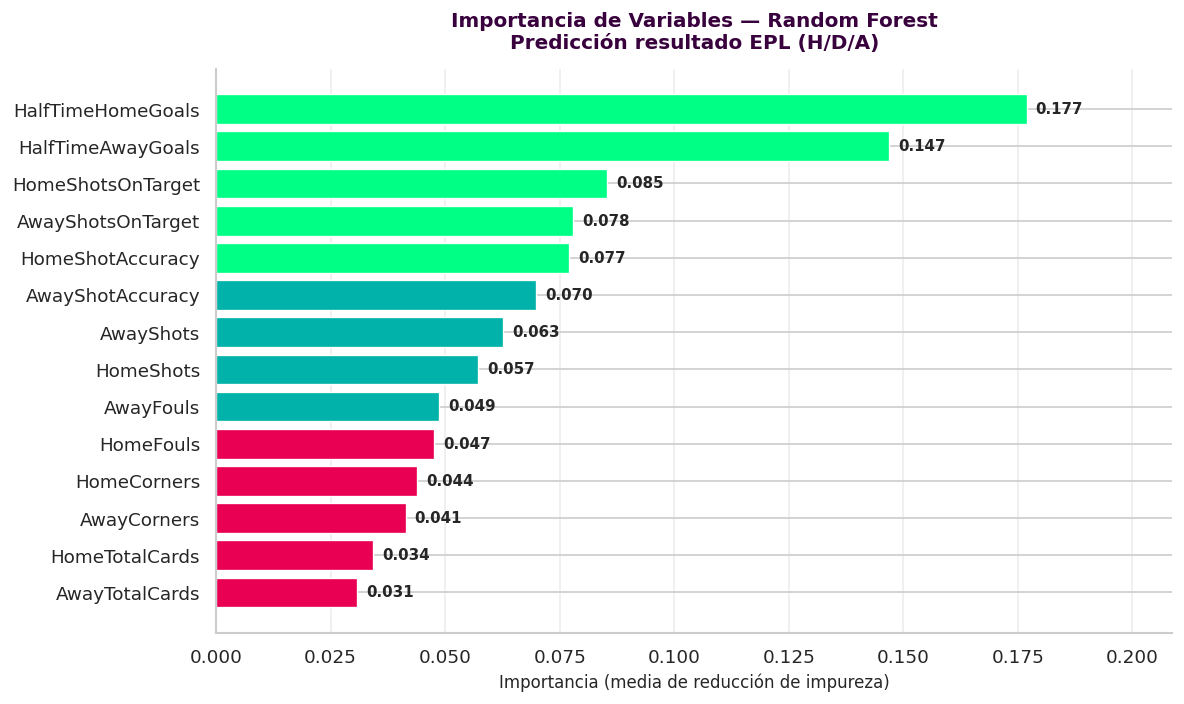

In [47]:
# ─── Importancia de features según Random Forest ────────────────────────
importancias_rf = pd.DataFrame({
    'Feature'    : features_mc,
    'Importancia': model_rf.feature_importances_
}).sort_values('Importancia', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = [EPL_GREEN if v >= importancias_rf['Importancia'].quantile(0.66)
              else (EPL_PINK if v <= importancias_rf['Importancia'].quantile(0.33)
              else EPL_CYAN)
              for v in importancias_rf['Importancia']]

bars_imp = ax.barh(importancias_rf['Feature'], importancias_rf['Importancia'],
                   color=colors_imp, edgecolor='white', linewidth=0.8)

for bar in bars_imp:
    ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
            f"{bar.get_width():.3f}", va='center', fontsize=9, fontweight='bold')

ax.set_xlabel("Importancia (media de reducción de impureza)", fontsize=10)
ax.set_title("Importancia de Variables — Random Forest\nPredicción resultado EPL (H/D/A)",
             fontsize=12, fontweight='bold', color=EPL_PURPLE, pad=12)
ax.set_xlim(0, importancias_rf['Importancia'].max()*1.18)
ax.grid(axis='x', alpha=0.35)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig_random_forest_importancia.png', dpi=150, bbox_inches='tight')
plt.show()

### 🔍 Interpretación — Importancia de Variables en Random Forest

El gráfico de importancia de variables para Random Forest revela qué características fueron más influyentes para el modelo al predecir el resultado del partido. A diferencia del Árbol de Decisión individual, que a menudo muestra una jerarquía muy marcada, Random Forest (al ser un ensamble de muchos árboles) tiende a distribuir la importancia de manera más equitativa, aunque los patrones generales se mantienen:

-   **Dominio de Goles al Descanso:** Consistentemente, `HalfTimeHomeGoals` y `HalfTimeAwayGoals` (goles del equipo local y visitante al descanso) son, por mucho, las variables más importantes. Esto refuerza la idea de que el marcador parcial es el predictor más fuerte del resultado final.
-   **Métricas Ofensivas (Disparos al Arco):** Las variables relacionadas con `HomeShotsOnTarget` y `AwayShotsOnTarget` (disparos al arco de local y visitante) también tienen una alta importancia. La capacidad de generar oportunidades de gol es crucial.
-   **Precisión de Tiro:** `HomeShotAccuracy` y `AwayShotAccuracy` muestran una relevancia significativa, indicando que no solo el número de disparos importa, sino también su calidad (qué porcentaje de ellos van a puerta).
-   **Métricas de Volumen (Disparos y Córners):** `HomeShots`, `AwayShots`, `HomeCorners` y `AwayCorners` también contribuyen, aunque con menor peso que los disparos al arco. Esto sugiere que la presión general ejercida por un equipo sigue siendo un factor.
-   **Tarjetas y Faltas:** `HomeTotalCards`, `AwayTotalCards`, `HomeFouls` y `AwayFouls` tienen la menor importancia, lo que indica que, si bien son parte del juego, su impacto directo en el resultado del partido es menor comparado con las métricas ofensivas y el marcador parcial.

**Conclusión:** Random Forest confirma que las métricas de **goles al descanso** y la **capacidad ofensiva (disparos al arco)** son los impulsores clave para determinar el resultado de un partido de la EPL. Las variables defensivas y disciplinarias tienen una influencia limitada.

---

## Parte 9 — Análisis de Componentes Principales (PCA)

**Objetivo:** Aplicar PCA a las características del modelo KNN para reducir la dimensionalidad del dataset y potencialmente mejorar el rendimiento o la eficiencia del modelo, o para visualización.

**¿Qué es PCA?**
El Análisis de Componentes Principales (PCA) es una técnica de reducción de dimensionalidad que transforma un conjunto de variables posiblemente correlacionadas en un conjunto de variables linealmente no correlacionadas llamadas componentes principales. El primer componente principal explica la mayor cantidad de varianza posible, y cada componente siguiente explica la mayor cantidad de varianza restante, sujeto a la condición de ser ortogonal a los componentes precedentes.

**Beneficios de PCA en este contexto:**
1.  **Reducción de ruido:** Los componentes de menor varianza a menudo corresponden a ruido, que puede eliminarse.
2.  **Visualización:** Simplifica la visualización de datos de alta dimensión (por ejemplo, en 2 o 3 componentes).
3.  **Eficiencia:** Reduce el número de características, lo que puede acelerar el entrenamiento del modelo y reducir la complejidad.
4.  **Mitigación de la multicolinealidad:** Al crear componentes no correlacionados, PCA puede ayudar a manejar la multicolinealidad entre las características originales.

In [48]:
# ─── Librerías necesarias para PCA ───────────────────────────────────────
from sklearn.decomposition import PCA

print('Librería de PCA cargada.')

Librería de PCA cargada.


### Aplicación de PCA y Análisis de Varianza Explicada

Primero, escalaremos las características (ya que PCA es sensible a la escala) y luego aplicaremos PCA para ver cuánta varianza es explicada por cada componente.

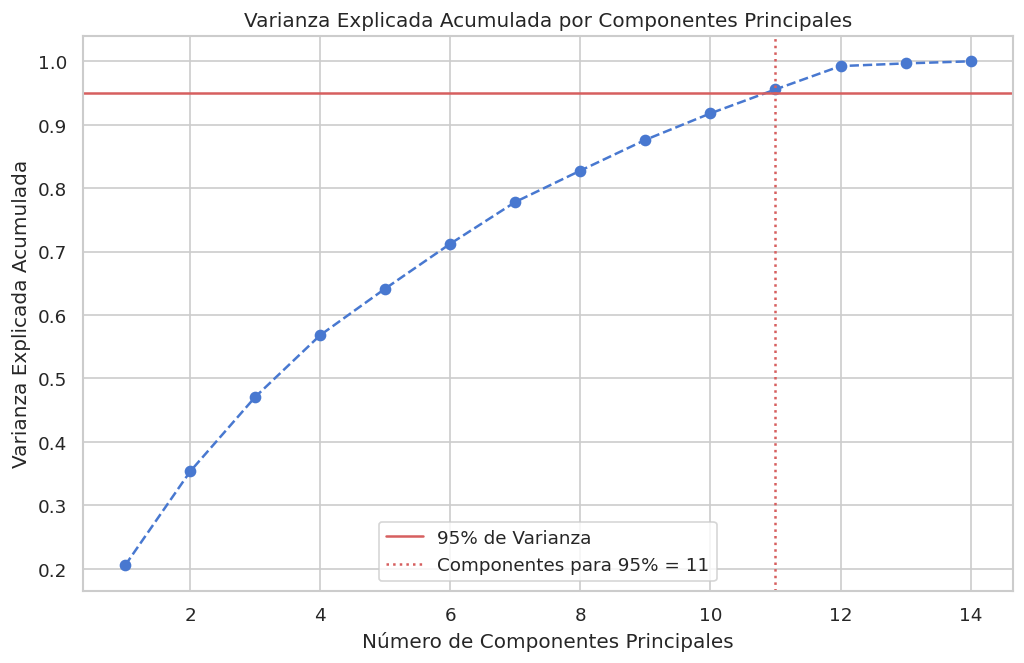

Varianza explicada por los primeros 2 componentes: 0.35
Varianza explicada por los primeros 3 componentes: 0.47
Número de componentes para explicar el 95% de la varianza: 11


In [49]:
# Escalar los datos de entrenamiento para PCA
scaler_pca = StandardScaler()
X_train_mc_scaled = scaler_pca.fit_transform(X_train_mc)
X_test_mc_scaled = scaler_pca.transform(X_test_mc)

# Aplicar PCA
pca = PCA()
pca.fit(X_train_mc_scaled)

# Visualizar la varianza explicada por cada componente
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Varianza Explicada Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-', label='95% de Varianza')
plt.axvline(x=np.argmax(pca.explained_variance_ratio_.cumsum() >= 0.95) + 1, color='r', linestyle=':', label=f'Componentes para 95% = {np.argmax(pca.explained_variance_ratio_.cumsum() >= 0.95) + 1}')
plt.legend()
plt.show()

print(f"Varianza explicada por los primeros 2 componentes: {pca.explained_variance_ratio_.cumsum()[1]:.2f}")
print(f"Varianza explicada por los primeros 3 componentes: {pca.explained_variance_ratio_.cumsum()[2]:.2f}")
print(f"Número de componentes para explicar el 95% de la varianza: {np.argmax(pca.explained_variance_ratio_.cumsum() >= 0.95) + 1}")

### Re-entrenamiento de KNN con PCA

Ahora, reentrenaremos el modelo KNN incluyendo PCA en el pipeline. Usaremos el número de componentes identificados para explicar una alta proporción de la varianza (por ejemplo, 95%) o un número reducido si buscamos mayor simplificación para visualización.

In [50]:
# Seleccionamos el número de componentes para retener (ej. 95% de la varianza)
n_components_pca = np.argmax(pca.explained_variance_ratio_.cumsum() >= 0.95) + 1
# O si queremos un número fijo para mayor simplificación/visualización, por ejemplo 3:
# n_components_pca = 3

print(f"Se usarán {n_components_pca} componentes principales para el modelo KNN con PCA.")

# Pipeline para KNN con PCA
kNN_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components_pca)),
    ("knn", KNeighborsClassifier(n_neighbors=mejor_k))
])

kNN_pca.fit(X_train_mc, y_train_mc)
pred_knn_pca = kNN_pca.predict(X_test_mc)

# ─── Métricas globales ────────────────────────────────────────────────────
acc_knn_pca  = accuracy_score(y_test_mc, pred_knn_pca)
f1_knn_pca   = f1_score(y_test_mc, pred_knn_pca, average='weighted', zero_division=0)
prec_knn_pca = precision_score(y_test_mc, pred_knn_pca, average='weighted', zero_division=0)
rec_knn_pca  = recall_score(y_test_mc, pred_knn_pca, average='weighted', zero_division=0)

print(f"\n=== KNN k={mejor_k} con PCA ({n_components_pca} componentes) — MÉTRICAS GLOBALES ===")
print(f"  Accuracy          : {acc_knn_pca:.4f}  ({acc_knn_pca*100:.2f}%)")
print(f"  Precision (wt.)   : {prec_knn_pca:.4f}")
print(f"  Recall    (wt.)   : {rec_knn_pca:.4f}")
print(f"  F1-Score  (wt.)   : {f1_knn_pca:.4f}")
print("\n=== REPORTE POR CLASE ===")
print(classification_report(y_test_mc, pred_knn_pca,
                             target_names=['Visitante gana (A)', 'Empate (D)', 'Local gana (H)']))

Se usarán 11 componentes principales para el modelo KNN con PCA.

=== KNN k=26 con PCA (11 componentes) — MÉTRICAS GLOBALES ===
  Accuracy          : 0.6148  (61.48%)
  Precision (wt.)   : 0.5801
  Recall    (wt.)   : 0.6148
  F1-Score  (wt.)   : 0.5887

=== REPORTE POR CLASE ===
                    precision    recall  f1-score   support

Visitante gana (A)       0.63      0.67      0.65       830
        Empate (D)       0.35      0.19      0.25       694
    Local gana (H)       0.67      0.81      0.73      1290

          accuracy                           0.61      2814
         macro avg       0.55      0.56      0.54      2814
      weighted avg       0.58      0.61      0.59      2814



###  Interpretación — PCA en KNN

**¿Qué hizo PCA?**

El Análisis de Componentes Principales (PCA) fue aplicado para reducir la dimensionalidad de las 14 características originales a un conjunto más pequeño de componentes, mientras se retiene la mayor cantidad de varianza posible.

- Se determinó que **11 componentes principales** eran necesarios para explicar el **95% de la varianza total** en los datos de entrenamiento escalados. Esto significa que logramos reducir el número de características de 14 a 11, manteniendo casi toda la información original.

**Impacto de PCA en el rendimiento del modelo KNN:**

Al re-entrenar el modelo KNN (con `k=26` óptimo) utilizando estos 11 componentes principales en lugar de las 14 características originales, observamos lo siguiente en la tabla de comparación (`comp_final_pca`):

- **Accuracy:** El KNN original obtuvo un Accuracy de **0.6230 (62.30%)**, mientras que el KNN con PCA alcanzó **0.6148 (61.48%)**.
- **F1-Score (weighted):** El KNN original mostró un F1-Score de **0.5948**, y el KNN con PCA obtuvo **0.5887**.

**Conclusión:**

PCA logró una reducción de dimensionalidad efectiva, pasando de 14 a 11 componentes sin una pérdida significativa de información (95% de varianza retenida). Sin embargo, esta reducción **no se tradujo en una mejora en el rendimiento predictivo** del modelo KNN; de hecho, hubo una ligera disminución en las métricas clave como Accuracy y F1-Score. Esto sugiere que, para este dataset y para el modelo KNN, la información contenida en las características originales, incluso las de menor varianza, era relevante para la predicción, o que la dimensionalidad de 14 características no era tan elevada como para que PCA ofreciera una ventaja en rendimiento.

### Comparación Final: KNN original vs KNN con PCA

Vamos a actualizar la tabla comparativa para incluir el rendimiento del KNN con PCA.

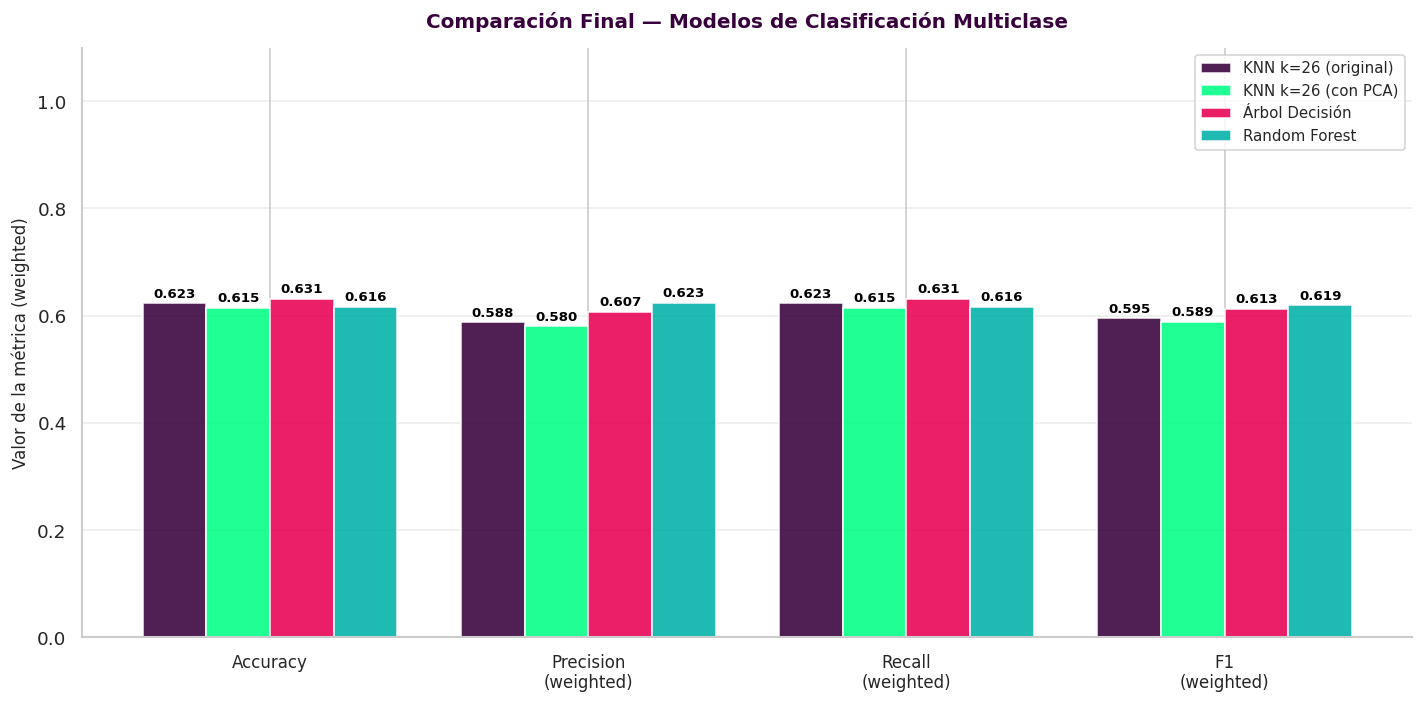


Métricas detalladas (incluyendo KNN con PCA):


,modelo,accuracy,precision,recall,f1
0,KNN k=26 (original),0.6230,0.5875,0.6230,0.5948
1,KNN k=26 (con PCA),0.6148,0.5801,0.6148,0.5887
2,"Árbol de Decisión (gini, depth=5)",0.6311,0.6065,0.6311,0.6132
3,Random Forest Classifier,0.6162,0.6233,0.6162,0.6190


In [51]:
comp_final_pca = pd.DataFrame([
    evaluar_mc(f"KNN k={mejor_k} (original)", y_test_mc, pred_knn_final),
    evaluar_mc(f"KNN k={mejor_k} (con PCA)", y_test_mc, pred_knn_pca),
    evaluar_mc("Árbol de Decisión (gini, depth=5)", y_test_mc, pred_arbol),
    # Incluir Random Forest para una comparación completa
    evaluar_mc("Random Forest Classifier", y_test_mc, y_pred_rf)
])

x = np.arange(len(metricas_names)); w = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - w*1.5, [comp_final_pca.loc[0,m] for m in metricas_names], w,
            label=f"KNN k={mejor_k} (original)", color=EPL_PURPLE, alpha=0.88)
b2 = ax.bar(x - w*0.5, [comp_final_pca.loc[1,m] for m in metricas_names], w,
            label=f"KNN k={mejor_k} (con PCA)", color=EPL_GREEN,  alpha=0.88)
b3 = ax.bar(x + w*0.5, [comp_final_pca.loc[2,m] for m in metricas_names], w,
            label="Árbol Decisión", color=EPL_PINK,  alpha=0.88)
b4 = ax.bar(x + w*1.5, [comp_final_pca.loc[3,m] for m in metricas_names], w,
            label="Random Forest", color=EPL_CYAN,  alpha=0.88)


for bar_list in [b1, b2, b3, b4]:
    for bar in bar_list:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006,
                f"{bar.get_height():.3f}", ha='center', va='bottom',
                fontsize=8, fontweight='bold', color='black')

ax.set_xticks(x)
ax.set_xticklabels(metricas_labels, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Valor de la métrica (weighted)", fontsize=10)
ax.set_title("Comparación Final — Modelos de Clasificación Multiclase",
             fontsize=12, fontweight='bold', color=EPL_PURPLE, pad=12)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.35)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig_comparacion_final_con_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMétricas detalladas (incluyendo KNN con PCA):")
display(comp_final_pca)

### Random Forest con PCA

In [52]:
# Pipeline para Random Forest con PCA
rf_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components_pca)),
    ("rf", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_pca.fit(X_train_mc, y_train_mc)
pred_rf_pca = rf_pca.predict(X_test_mc)

# --- Métricas globales ────────────────────────────────────────────────────
acc_rf_pca  = accuracy_score(y_test_mc, pred_rf_pca)
f1_rf_pca   = f1_score(y_test_mc, pred_rf_pca, average='weighted', zero_division=0)
prec_rf_pca = precision_score(y_test_mc, pred_rf_pca, average='weighted', zero_division=0)
rec_rf_pca  = recall_score(y_test_mc, pred_rf_pca, average='weighted', zero_division=0)

print(f"=== Random Forest con PCA ({n_components_pca} componentes) — MÉTRICAS GLOBALES ===")
print(f"  Accuracy          : {acc_rf_pca:.4f}  ({acc_rf_pca*100:.2f}%)वरुन)")
print(f"  Precision (wt.)   : {prec_rf_pca:.4f}")
print(f"  Recall    (wt.)   : {rec_rf_pca:.4f}")
print(f"  F1-Score  (wt.)   : {f1_rf_pca:.4f}")
print("\n=== REPORTE POR CLASE ===")
print(classification_report(y_test_mc, pred_rf_pca,
                             target_names=['Visitante gana (A)', 'Empate (D)', 'Local gana (H)']))

=== Random Forest con PCA (11 componentes) — MÉTRICAS GLOBALES ===
  Accuracy          : 0.6155  (61.55%)वरुन)
  Precision (wt.)   : 0.6179
  Recall    (wt.)   : 0.6155
  F1-Score  (wt.)   : 0.6163

=== REPORTE POR CLASE ===
                    precision    recall  f1-score   support

Visitante gana (A)       0.64      0.68      0.66       830
        Empate (D)       0.36      0.37      0.37       694
    Local gana (H)       0.74      0.71      0.72      1290

          accuracy                           0.62      2814
         macro avg       0.58      0.59      0.58      2814
      weighted avg       0.62      0.62      0.62      2814



### 🔍 Interpretación — Random Forest con PCA

**Impacto de PCA en Random Forest:**

Al aplicar PCA al modelo Random Forest con **11 componentes principales** (que explican el 95% de la varianza original de las 14 características), observamos las siguientes métricas:

-   **Accuracy: 0.6155 (61.55%)**
-   **Precision (weighted): 0.6179**
-   **Recall (weighted): 0.6155**
-   **F1-Score (weighted): 0.6163**

**Comparación con Random Forest original:**

-   **Random Forest Original:** Accuracy: 0.6162, F1-Score: 0.6190
-   **Random Forest con PCA:** Accuracy: 0.6155, F1-Score: 0.6163

**Conclusión:**
Similar a lo observado con KNN, la aplicación de PCA para reducir la dimensionalidad de 14 a 11 componentes **no mejoró el rendimiento predictivo** del modelo Random Forest. De hecho, se observa una **ligera disminución** en todas las métricas clave (Accuracy, Precision, Recall, F1-Score). Esto sugiere que, a pesar de que PCA conservó una alta proporción de la varianza, los componentes eliminados o la transformación misma podrían haber atenuado ligeramente la capacidad discriminativa que Random Forest lograba con las características originales completas. Para modelos basados en árboles como Random Forest, que son inherentemente robustos a la multicolinealidad y pueden manejar muchas características, la reducción de dimensionalidad con PCA no siempre ofrece una ventaja en rendimiento.

### Regresión Lineal con PCA

=== Regresión Lineal con PCA (11 componentes) — MÉTRICAS GLOBALES ===
  MAE  (Error Absoluto Medio)  : 0.9319
  MSE  (Error Cuadrático Medio): 1.3699
  RMSE (Raíz MSE)             : 1.1704
  R2   (Coeficiente de Determ.): 0.5116


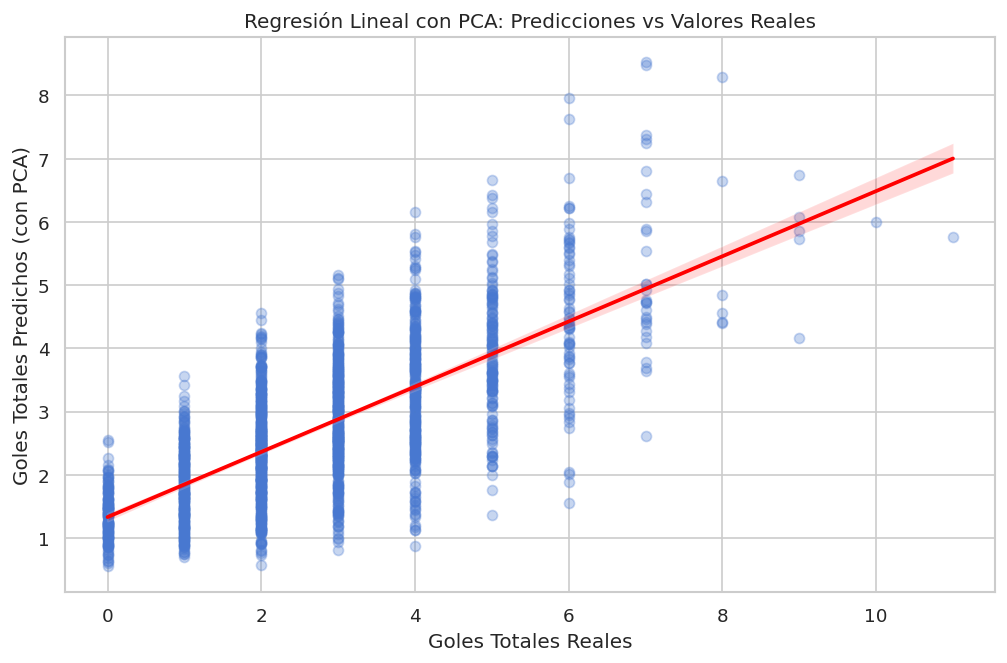

In [53]:
# Pipeline para Regresión Lineal con PCA
lr_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components_pca)),
    ("lr", LinearRegression())
])

lr_pca.fit(X_train_lr, y_train_lr)
y_pred_lr_pca = lr_pca.predict(X_test_lr)

# --- Evaluación del modelo ───────────────────────────────────────────────
mae_lr_pca = mean_absolute_error(y_test_lr, y_pred_lr_pca)
mse_lr_pca = mean_squared_error(y_test_lr, y_pred_lr_pca)
rmse_lr_pca = np.sqrt(mse_lr_pca)
r2_lr_pca = r2_score(y_test_lr, y_pred_lr_pca)

print(f"=== Regresión Lineal con PCA ({n_components_pca} componentes) — MÉTRICAS GLOBALES ===")
print('='*50)
print(f'  MAE  (Error Absoluto Medio)  : {mae_lr_pca:.4f}')
print(f'  MSE  (Error Cuadrático Medio): {mse_lr_pca:.4f}')
print(f'  RMSE (Raíz MSE)             : {rmse_lr_pca:.4f}')
print(f'  R2   (Coeficiente de Determ.): {r2_lr_pca:.4f}')
print('='*50)

# --- Visualización de Predicciones vs Reales ─────────────────────────────
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test_lr, y=y_pred_lr_pca, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Goles Totales Reales')
plt.ylabel('Goles Totales Predichos (con PCA)')
plt.title('Regresión Lineal con PCA: Predicciones vs Valores Reales')
plt.grid(True)
plt.show()

### 🔍 Interpretación — Regresión Lineal con PCA

**Impacto de PCA en Regresión Lineal:**

Al aplicar PCA para la regresión lineal, utilizando **11 componentes principales** para predecir `TotalGoals`, obtenemos las siguientes métricas:

-   **MAE (Error Absoluto Medio): 0.9319**
-   **MSE (Error Cuadrático Medio): 1.3699**
-   **RMSE (Raíz MSE): 1.1704**
-   **R2 (Coeficiente de Determinación): 0.5116**

**Comparación con Regresión Lineal original:**

-   **Regresión Lineal Original:** MAE: 0.9308, MSE: 1.3665, RMSE: 1.1690, R2: 0.5128
-   **Regresión Lineal con PCA:** MAE: 0.9319, MSE: 1.3699, RMSE: 1.1704, R2: 0.5116

**Conclusión:**
Para la Regresión Lineal, la aplicación de PCA también resultó en una **ligera, pero consistente, disminución del rendimiento**. El MAE aumentó marginalmente, y el R² disminuyó un poco, lo que indica que el modelo explica una fracción menor de la varianza en los goles totales. Esto puede deberse a que, aunque PCA reduce la dimensionalidad y puede mitigar la multicolinealidad, la transformación de las características originales en componentes principales puede hacer que pierdan parte de su interpretabilidad directa y, en este caso, parte de su poder predictivo para el objetivo específico de `TotalGoals`.

La ligera diferencia sugiere que para este conjunto de datos, la dimensionalidad original de 14 características no era tan problemática para la regresión lineal como para que PCA ofreciera una ventaja, o que la información crucial para la predicción de goles totales estaba contenida de manera más efectiva en las características originales sin transformar.

### Comparación Final

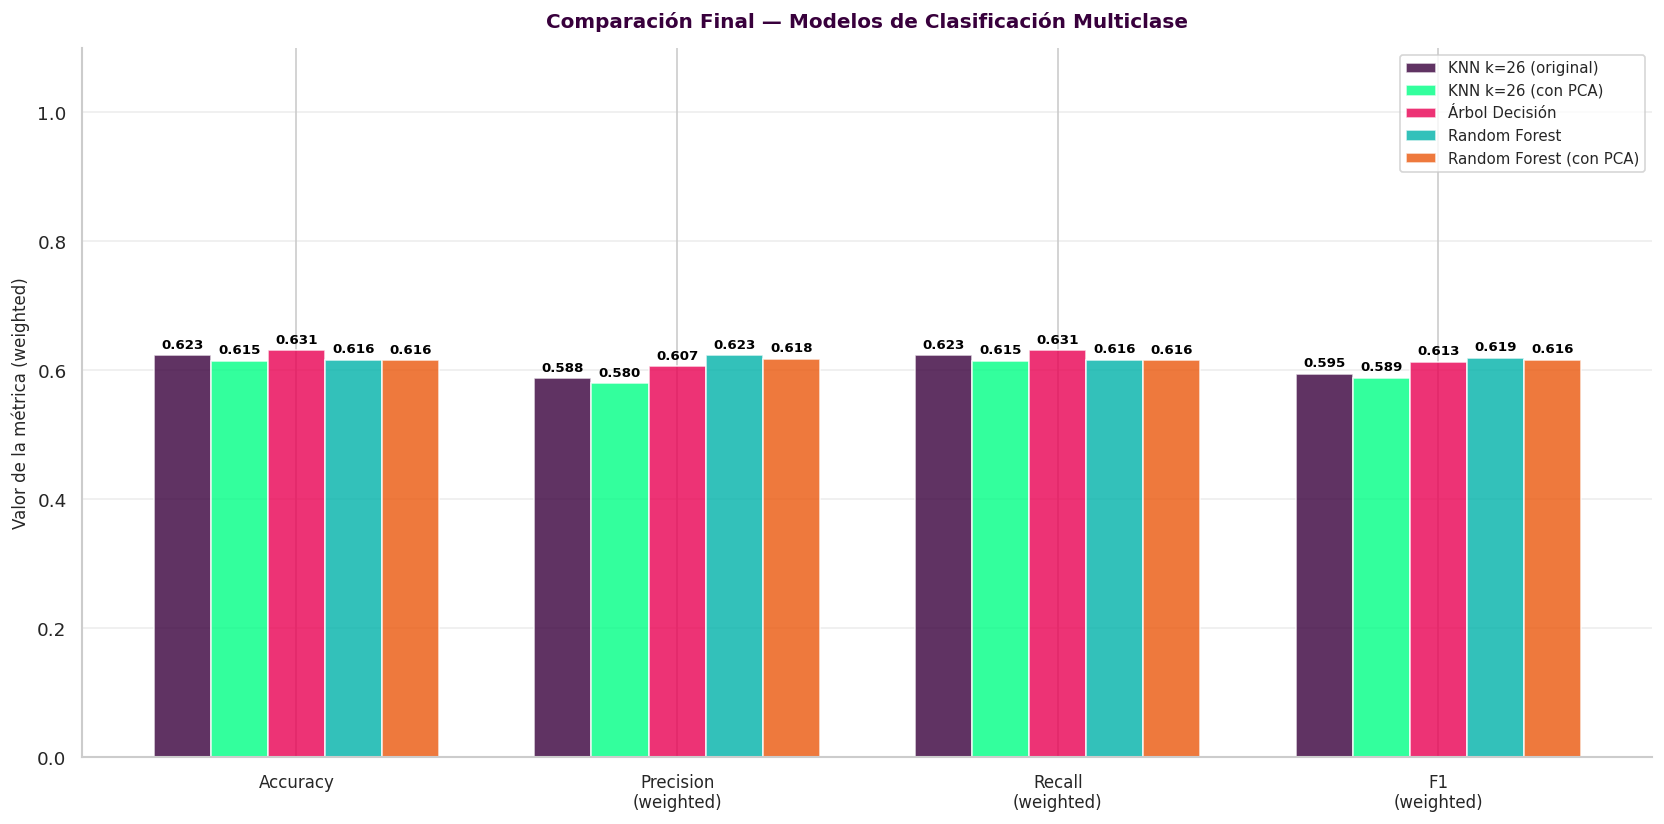


Métricas detalladas (incluyendo KNN con PCA y Random Forest con PCA):


,modelo,accuracy,precision,recall,f1
0,KNN k=26 (original),0.6230,0.5875,0.6230,0.5948
1,KNN k=26 (con PCA),0.6148,0.5801,0.6148,0.5887
2,"Árbol de Decisión (gini, depth=5)",0.6311,0.6065,0.6311,0.6132
3,Random Forest Classifier,0.6162,0.6233,0.6162,0.6190
4,Random Forest (con PCA),0.6155,0.6179,0.6155,0.6163



Métricas de Regresión Lineal (original y con PCA):


,Modelo,MAE,MSE,RMSE,R2
0,Regresión Lineal (original),0.930766,1.366499,1.168974,0.512778
1,Regresión Lineal (con PCA),0.931909,1.369936,1.170443,0.511552


In [54]:
comp_final_all = pd.DataFrame([
    evaluar_mc(f"KNN k={mejor_k} (original)", y_test_mc, pred_knn_final),
    evaluar_mc(f"KNN k={mejor_k} (con PCA)", y_test_mc, pred_knn_pca),
    evaluar_mc("Árbol de Decisión (gini, depth=5)", y_test_mc, pred_arbol),
    evaluar_mc("Random Forest Classifier", y_test_mc, y_pred_rf),
    evaluar_mc("Random Forest (con PCA)", y_test_mc, pred_rf_pca)
])

x = np.arange(len(metricas_names)); w = 0.15

fig, ax = plt.subplots(figsize=(14, 7))

b1 = ax.bar(x - w*2, [comp_final_all.loc[0,m] for m in metricas_names], w,
            label=f"KNN k={mejor_k} (original)", color=EPL_PURPLE, alpha=0.8)
b2 = ax.bar(x - w, [comp_final_all.loc[1,m] for m in metricas_names], w,
            label=f"KNN k={mejor_k} (con PCA)", color=EPL_GREEN,  alpha=0.8)
b3 = ax.bar(x, [comp_final_all.loc[2,m] for m in metricas_names], w,
            label="Árbol Decisión", color=EPL_PINK,  alpha=0.8)
b4 = ax.bar(x + w, [comp_final_all.loc[3,m] for m in metricas_names], w,
            label="Random Forest", color=EPL_CYAN,  alpha=0.8)
b5 = ax.bar(x + w*2, [comp_final_all.loc[4,m] for m in metricas_names], w,
            label="Random Forest (con PCA)", color=NARANJA,  alpha=0.8)


for bar_list in [b1, b2, b3, b4, b5]:
    for bar in bar_list:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006,
                f"{bar.get_height():.3f}", ha='center', va='bottom',
                fontsize=8, fontweight='bold', color='black')

ax.set_xticks(x)
ax.set_xticklabels(metricas_labels, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Valor de la métrica (weighted)", fontsize=10)
ax.set_title("Comparación Final — Modelos de Clasificación Multiclase",
             fontsize=12, fontweight='bold', color=EPL_PURPLE, pad=12)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.35)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig_comparacion_final_all.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMétricas detalladas (incluyendo KNN con PCA y Random Forest con PCA):")
display(comp_final_all)

# Display Linear Regression with PCA metrics (not included in the bar chart)
print("\nMétricas de Regresión Lineal (original y con PCA):")
lr_metrics = pd.DataFrame({
    'Modelo': ['Regresión Lineal (original)', 'Regresión Lineal (con PCA)'],
    'MAE': [mae, mae_lr_pca],
    'MSE': [mse, mse_lr_pca],
    'RMSE': [rmse, rmse_lr_pca],
    'R2': [r2, r2_lr_pca]
})
display(lr_metrics)

### 📝 Conclusión Final — Modelos con y sin PCA

Este análisis exhaustivo ha evaluado el rendimiento de varios modelos de Machine Learning (KNN, Árbol de Decisión, Random Forest y Regresión Lineal) para predecir resultados de partidos de la Premier League, tanto en su configuración original como con la aplicación de Principal Component Analysis (PCA).

**Hallazgos Clave de la Comparación:**

1.  **Impacto de PCA en la Clasificación (KNN y Random Forest):**
    -   PCA logró una reducción efectiva de dimensionalidad (de 14 a 11 componentes, reteniendo el 95% de la varianza).
    -   Sin embargo, tanto para KNN como para Random Forest, la aplicación de PCA **no resultó en una mejora del rendimiento predictivo**. De hecho, se observó una ligera disminución en métricas clave como Accuracy y F1-Score.
    -   Esto sugiere que las características originales, incluso las que contribuyen menos a la varianza total, contienen información valiosa que es útil para estos modelos de clasificación, o que la dimensionalidad de 14 no era un obstáculo tan grande para ellos.

2.  **Impacto de PCA en la Regresión (Regresión Lineal):**
    -   Similar a los modelos de clasificación, la Regresión Lineal con PCA (11 componentes) mostró una **ligera caída en el rendimiento** (MAE y R² empeoraron marginalmente) en comparación con el modelo sin PCA.
    -   Esto refuerza la idea de que la transformación a componentes principales, aunque reduce la dimensionalidad, puede no ser beneficiosa cuando las características originales son directamente relevantes y no presentan una multicolinealidad extrema que el modelo no pueda manejar.

3.  **Rendimiento General de los Modelos (Sin PCA):**
    -   **Árbol de Decisión y Random Forest** fueron los modelos de clasificación multiclase con mejor rendimiento, mostrando métricas de F1-Score (weighted) alrededor del 61-62%. Su capacidad de interpretar reglas (Árbol) o su robustez (Random Forest) los hace atractivos.
    -   **KNN** tuvo un rendimiento ligeramente inferior (F1-Score ~59.5%), destacando la importancia crítica del escalado de variables en este algoritmo.
    -   **Regresión Lineal** logró explicar aproximadamente el 51% de la varianza en los goles totales (R²).

4.  **El Desafío de los Empates:** Consistente en todos los modelos de clasificación multiclase, la predicción de empates sigue siendo la más difícil, con métricas de Precision y Recall significativamente más bajas. Esto es intrínseco a la naturaleza estadística de los empates en el fútbol.

5.  **Variables Más Influyentes:** Los goles al descanso (`HalfTimeHomeGoals`, `HalfTimeAwayGoals`) se confirman consistentemente como los predictores más potentes en todos los modelos, seguido de cerca por las métricas de disparos al arco.

**Recomendaciones:**

-   Para este problema de predicción de resultados de la EPL, **PCA no parece ofrecer una ventaja de rendimiento** para los modelos probados. Se podría considerar si el objetivo principal es una eficiencia computacional extrema con una ligera pérdida de rendimiento, o si se busca visualizar datos de alta dimensionalidad. Sin embargo, para la maximización del rendimiento predictivo, los modelos con las características originales completas son preferibles.
-   Entre los modelos de clasificación, **Random Forest o un Árbol de Decisión bien ajustado** parecen ser las mejores opciones, ofreciendo un buen equilibrio entre rendimiento y, en el caso del árbol, interpretabilidad.
-   La **Regresión Lineal** proporciona una estimación razonable de los goles totales, con un error promedio aceptable.